<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula03-regressao-logistica/aula03-gabarito.ipynb)

# Aula Prática 03 - Regressão Logística - Gabarito

**Inteligência Artificial - Graduação**
Prof. Bruno Nogueira - FACOM/UFMS - 2026/2

---

## Do que trata esta aula

Na aula 02 construímos a regressão linear para prever **números**: o consumo de um
carro, o preço de uma casa. Hoje voltamos à **classificação** - a pergunta é de novo
"de que lado?" - mas levando junto toda a maquinaria da regressão: hipótese,
parâmetros $\theta$, função de custo, gradiente descendente.

O nome **regressão logística** é, por isso, uma pequena traição: apesar do nome, é um
algoritmo de **classificação**. O que ele faz de regressão é estimar um número
contínuo - a **probabilidade** de o exemplo pertencer à classe 1 - e só depois cortar
esse número num limiar.

A pergunta central da aula é geométrica: **onde exatamente o modelo troca de
opinião?** Esse lugar tem nome, **fronteira de decisão** (ou *borda de decisão*), e
hoje vamos desenhá-la em todos os gráficos.

Diferente da aula 02, aqui o algoritmo é do **scikit-learn**: a implementação do
gradiente descendente para a regressão logística fica para o exercício da teoria e
para a próxima aula prática. O foco de hoje é **entender e visualizar** o que o
modelo faz.

### Roteiro

| # | Tema | Conceito da teoria |
|---|------|--------------------|
| 1 | A base: três espécies de pinguim | classificação binária |
| 2 | Por que não usar a regressão linear? | limiar sobre $\theta^T x$ falha |
| 3 | A função logística | $g(z) = \dfrac{1}{1 + e^{-z}}$ |
| 4 | Regressão logística em 1 atributo | $h(x) = g(\theta^T x)$, probabilidade |
| 5 | A fronteira de decisão | $h(x) \geq 0{,}5 \Leftrightarrow \theta^T x \geq 0$ |
| 6 | Fronteira em 2 atributos | a reta $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$ |
| 7 | Escolhendo $\theta$ na mão | o exemplo $\theta = [-3, 1, 1]$ dos slides |
| 8 | Fronteiras não lineares | termos polinomiais, o círculo dos slides |
| 9 | Complexidade demais | overfitting e a Navalha de Ockham |
| 10 | O limiar não precisa ser 0,5 | precisão × revocação |
| 11 | Mais de duas classes | *softmax* e três regiões |

> **Gabarito.** Este é o mesmo notebook da aula, com as lacunas preenchidas e todas as células executadas. As respostas das perguntas de interpretação estão em células de markdown marcadas com **🎯 Conclusão**.

---
## 0. Preparando o ambiente

As mesmas bibliotecas das aulas anteriores. A novidade é o módulo
`sklearn.linear_model.LogisticRegression`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

# Semente aleatória: garante que TODOS na sala obtenham os mesmos números.
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta segura para daltônicos, a mesma das aulas 01 e 02.
CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
# Versões clarinhas das duas primeiras, para pintar as REGIÕES de decisão ao fundo.
MAPA_REGIOES = ListedColormap(["#D6DEEC", "#F7DFCE"])

print(f"NumPy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print("\nAmbiente pronto.")

NumPy        2.4.4
pandas       3.0.2
scikit-learn 1.8.0

Ambiente pronto.


---
## 1. A base: três espécies de pinguim

Os slides usam o problema dos **cogumelos**: comestível (1) ou não (0), a partir do
tamanho. É um exemplo perfeito para explicar a ideia, mas cogumelo de verdade se
classifica por atributos categóricos (cor do chapéu, tipo de anel), e hoje eu quero
**eixos numéricos** para poder desenhar fronteiras.

Então vamos de **Palmer Penguins**: 344 pinguins de três espécies medidos em três
ilhas do arquipélago Palmer, na Antártida, por Kristen Gorman. A base foi criada
justamente para substituir a Iris no ensino - mesmo formato, dados mais recentes e
com uma história bem documentada.

- **Referência:** GORMAN, K. B.; WILLIAMS, T. D.; FRASER, W. R. Ecological sexual
  dimorphism and environmental variability within a community of Antarctic penguins
  (genus *Pygoscelis*). *PLoS ONE*, v. 9, n. 3, e90081, 2014.
- **Atributos:** comprimento e profundidade do bico (mm), comprimento da nadadeira
  (mm), massa corporal (g), ilha e sexo.
- **Pergunta da aula:** dado o bico de um pinguim, ele é **Adélie** ou
  **Chinstrap** (de barbicha)?

In [2]:
CAMINHO_LOCAL = Path("../../dados/penguins.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
                "main/dados/penguins.csv")

if CAMINHO_LOCAL.exists():
    bruto = pd.read_csv(CAMINHO_LOCAL)
    print(f"Base carregada do arquivo local: {CAMINHO_LOCAL}")
else:
    bruto = pd.read_csv(URL_FALLBACK)
    print("Base baixada da internet.")

RENOMEAR = {
    "species": "especie", "island": "ilha", "bill_length_mm": "bico_comprimento",
    "bill_depth_mm": "bico_profundidade", "flipper_length_mm": "nadadeira",
    "body_mass_g": "massa_g", "sex": "sexo",
}
pinguins = bruto.rename(columns=RENOMEAR)

print(f"\n{pinguins.shape[0]} pinguins × {pinguins.shape[1]} colunas")
print(pinguins["especie"].value_counts().to_string())
print("\nValores ausentes por coluna:")
print(pinguins.isna().sum()[lambda s: s > 0].to_string())
pinguins.head()

Base carregada do arquivo local: ../../dados/penguins.csv

344 pinguins × 7 colunas
especie
Adelie       152
Gentoo       124
Chinstrap     68

Valores ausentes por coluna:
bico_comprimento      2
bico_profundidade     2
nadadeira             2
massa_g               2
sexo                 11


,especie,ilha,bico_comprimento,bico_profundidade,nadadeira,massa_g,sexo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Há 2 linhas com todas as medidas ausentes (pinguins que entraram na planilha só com
espécie e ilha) e 11 sem o sexo anotado. Como toda a aula usa as medidas do bico,
vamos descartar as linhas sem elas - e **anunciar** quantas foram, que é o mínimo de
honestidade com os dados.

In [3]:
COLUNAS_MEDIDAS = ["bico_comprimento", "bico_profundidade", "nadadeira", "massa_g"]
antes = len(pinguins)
pinguins = pinguins.dropna(subset=COLUNAS_MEDIDAS).reset_index(drop=True)
print(f"{antes - len(pinguins)} linhas descartadas por falta de medidas; "
      f"restaram {len(pinguins)}.")

print(pinguins.groupby("especie")[COLUNAS_MEDIDAS].mean().round(1).to_string())

2 linhas descartadas por falta de medidas; restaram 342.
           bico_comprimento  bico_profundidade  nadadeira  massa_g
especie                                                           
Adelie                 38.8               18.3      190.0   3700.7
Chinstrap              48.8               18.4      195.8   3733.1
Gentoo                 47.5               15.0      217.2   5076.0


Repare na tabela: **Adélie** e **Chinstrap** têm bico de profundidade praticamente
igual (18,3 mm contra 18,4 mm) e massa parecida - o que as separa é o **comprimento**
do bico (38,8 mm contra 48,8 mm). Já o **Gentoo** se destaca pelo bico raso e pela
nadadeira longa.

É exatamente o cenário que eu quero: duas classes que **um único atributo** já
separa bem (para a parte 1D), mas não perfeitamente (para haver erro sobre o que
conversar).

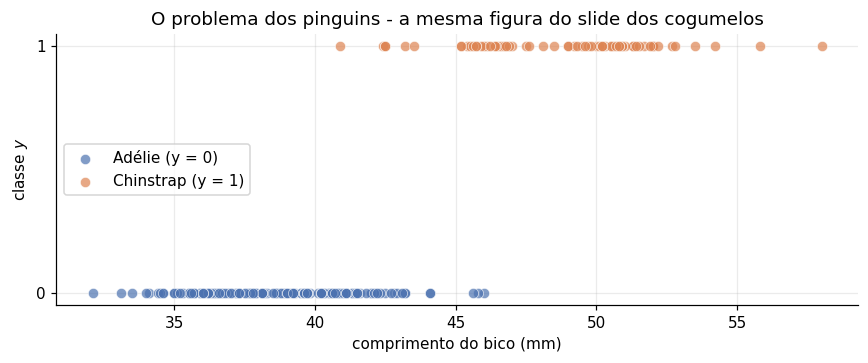

m = 219 exemplos    y = 1 em 31.1% deles
bico: de 32.1 a 58.0 mm

Erro do classificador majoritário (chutar sempre a classe mais frequente): 31.1%


In [4]:
# Nosso problema binário: Adélie (y = 0) contra Chinstrap (y = 1).
duas = pinguins[pinguins["especie"].isin(["Adelie", "Chinstrap"])].reset_index(drop=True)
NOMES_CLASSE = ["Adélie (y = 0)", "Chinstrap (y = 1)"]

x1d = duas["bico_comprimento"].to_numpy(dtype=float)
y = (duas["especie"] == "Chinstrap").astype(int).to_numpy()
m = y.size

fig, ax = plt.subplots(figsize=(8, 3.4))
for classe in (0, 1):
    marca = y == classe
    ax.scatter(x1d[marca], y[marca], s=45, alpha=0.7, edgecolor="white", linewidth=0.5,
               c=CORES[0] if classe == 0 else CORES[1], label=NOMES_CLASSE[classe],
               zorder=3)
ax.set_yticks([0, 1])
ax.set_yticklabels(["0", "1"])
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("classe $y$")
ax.set_title("O problema dos pinguins - a mesma figura do slide dos cogumelos")
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

print(f"m = {m} exemplos    y = 1 em {y.mean():.1%} deles")
print(f"bico: de {x1d.min():.1f} a {x1d.max():.1f} mm")
print(f"\nErro do classificador majoritário (chutar sempre a classe mais frequente): "
      f"{min(y.mean(), 1 - y.mean()):.1%}")

---
## 2. Por que não usar a regressão linear que já sabemos?

Nos slides: *"podemos pensar em adaptar o processo de regressão linear estabelecendo
um limiar (threshold)"*. A ideia é natural - já temos uma reta funcionando, então:

$$h(x) = \theta^T x, \qquad \text{prever } y = 1 \text{ se } h(x) \geq 0{,}5,
\qquad y = 0 \text{ caso contrário}$$

Vamos fazer exatamente isso, com o `LinearRegression` da aula 02, e observar onde
quebra.

In [5]:
from sklearn.linear_model import LinearRegression

X1d = x1d.reshape(-1, 1)   # convenção da aula 02: X é 2-D, y é 1-D

reta = LinearRegression().fit(X1d, y)
h_reta = reta.predict(X1d)
limiar_reta = (0.5 - reta.intercept_) / reta.coef_[0]   # onde h(x) = 0,5
pred_reta = (h_reta >= 0.5).astype(int)

print(f"h(x) = {reta.intercept_:.3f} + {reta.coef_[0]:.4f} · x")
print(f"A reta cruza 0,5 em x = {limiar_reta:.2f} mm")
print(f"Acurácia: {(pred_reta == y).mean():.1%}  ({(pred_reta != y).sum()} erros)")
print()
print(f"MENOR valor previsto: h(x) = {h_reta.min():+.3f}   (bico de {x1d.min():.1f} mm)")
print(f"MAIOR valor previsto: h(x) = {h_reta.max():+.3f}   (bico de {x1d.max():.1f} mm)")

h(x) = -2.707 + 0.0720 · x
A reta cruza 0,5 em x = 44.54 mm
Acurácia: 95.9%  (9 erros)

MENOR valor previsto: h(x) = -0.396   (bico de 32.1 mm)
MAIOR valor previsto: h(x) = +1.469   (bico de 58.0 mm)


🔎 **PARE E PENSE**: a acurácia é boa. Mas olhe as duas últimas linhas: o modelo
prevê $h(x) = -0{,}40$ para o menor bico e $h(x) = +1{,}47$ para o maior. Se
quisermos ler $h(x)$ como "chance de ser Chinstrap", o que significa **-40% de
chance**? E **147% de chance**?

É a primeira objeção dos slides: a regressão linear *"pode nos dar valores de classe
muito destoantes"*. Não existe limite superior nem inferior numa reta.

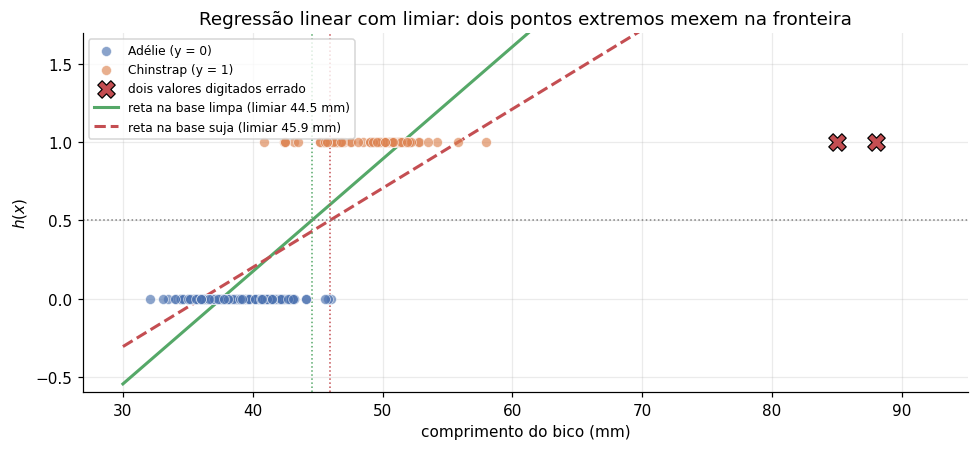

limiar antes: 44.54 mm   →   depois: 45.93 mm
erros nos dados limpos antes: 9   →   depois: 15


In [6]:
# A segunda objeção: uma reta é PUXADA por pontos extremos - e o limiar vai com ela.
# Suponha dois Chinstraps cujo bico foi digitado errado na planilha (85 e 88 mm, quando
# o maior bico real da base tem 58 mm). Nada mais na base muda.
x_sujo = np.append(x1d, [85.0, 88.0])
y_sujo = np.append(y, [1, 1])

reta_suja = LinearRegression().fit(x_sujo.reshape(-1, 1), y_sujo)
limiar_sujo = (0.5 - reta_suja.intercept_) / reta_suja.coef_[0]
pred_suja = (reta_suja.predict(X1d) >= 0.5).astype(int)   # avaliada nos dados LIMPOS

grade = np.linspace(30, 92, 400)

fig, ax = plt.subplots(figsize=(9, 4.2))
for classe in (0, 1):
    marca = y == classe
    ax.scatter(x1d[marca], y[marca], s=42, alpha=0.65, edgecolor="white", linewidth=0.5,
               c=CORES[0] if classe == 0 else CORES[1], label=NOMES_CLASSE[classe],
               zorder=3)
ax.scatter([85, 88], [1, 1], s=130, marker="X", c=CORES[3], edgecolor="black",
           linewidth=0.8, label="dois valores digitados errado", zorder=4)

ax.plot(grade, reta.predict(grade.reshape(-1, 1)), color=CORES[2], lw=2,
        label=f"reta na base limpa (limiar {limiar_reta:.1f} mm)")
ax.plot(grade, reta_suja.predict(grade.reshape(-1, 1)), color=CORES[3], lw=2, ls="--",
        label=f"reta na base suja (limiar {limiar_sujo:.1f} mm)")
ax.axhline(0.5, color="gray", lw=1, ls=":")
ax.axvline(limiar_reta, color=CORES[2], lw=1, ls=":")
ax.axvline(limiar_sujo, color=CORES[3], lw=1, ls=":")
ax.set_ylim(-0.6, 1.7)
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("$h(x)$")
ax.set_title("Regressão linear com limiar: dois pontos extremos mexem na fronteira")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

print(f"limiar antes: {limiar_reta:.2f} mm   →   depois: {limiar_sujo:.2f} mm")
print(f"erros nos dados limpos antes: {(pred_reta != y).sum()}   →   "
      f"depois: {(pred_suja != y).sum()}")

A fronteira andou mais de um milímetro para a direita e o número de erros **nos
mesmos dados limpos** subiu de 9 para 15. Os dois pontos não trouxeram informação
nova nenhuma - eram Chinstraps, e Chinstrap já era a classe 1 daquele lado - mas a
reta, que tenta minimizar o **erro quadrático até esses pontos**, se deitou para
alcançá-los.

É a lição dos slides: *"essa não é uma boa opção; falha em muitos casos"*. O problema
de fundo é que a regressão linear tenta acertar o **valor** 0 ou 1, quando o que nos
interessa é apenas **de que lado** o ponto está.

---
## 3. A função logística (ou sigmoide)

A solução dos slides é comprimir a saída para dentro de $[0, 1]$:

$$g(z) = \frac{1}{1 + e^{-z}}, \qquad z \in \mathbb{R}$$

Três propriedades importam:

1. $0 < g(z) < 1$ para todo $z$ - **nunca** toca 0 nem 1, só tende a eles;
2. $g(0) = 0{,}5$ exatamente - o meio da escala fica em $z = 0$;
3. $g(-z) = 1 - g(z)$ - é simétrica em torno desse meio.

### 🔨 IMPLEMENTE 1 - a função logística

In [7]:
def sigmoide(z):
    """Função logística, aplicada elemento a elemento.

    Parâmetros
    ----------
    z : float ou np.ndarray

    Devolve
    -------
    np.ndarray com 1 / (1 + e^-z)
    """
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

In [8]:
# Conferência da IMPLEMENTE 1
assert np.isclose(sigmoide(0.0), 0.5), "g(0) tem que ser exatamente 0,5"
assert np.isclose(sigmoide(2.0), 0.8807970779778823, atol=1e-12), "confira a fórmula"
assert np.isclose(sigmoide(-2.0), 1 - sigmoide(2.0)), "g(-z) = 1 - g(z)"
z_teste = np.linspace(-30, 30, 61)
g_teste = sigmoide(z_teste)
assert np.all((g_teste > 0) & (g_teste < 1)), "g(z) nunca chega a 0 nem a 1"
assert np.all(np.diff(g_teste) > 0), "g(z) é crescente"
assert sigmoide([0, 0]).shape == (2,), "deve funcionar em vetores"
print("OK - sigmoide correta.")
print(f"g(-6) = {sigmoide(-6):.6f}    g(0) = {sigmoide(0):.6f}    g(6) = {sigmoide(6):.6f}")
print()
print("Curiosidade de ponto flutuante: na matemática g(z) < 1 sempre, mas o float64")
print(f"tem casas finitas - g(36) = {sigmoide(36.0):.17f} ainda cabe, e")
print(f"g(37) = {sigmoide(37.0):.1f} já arredonda para 1 exato. Bibliotecas sérias")
print("evitam isso trabalhando com log(h(x)) em vez de h(x) - é o que o scikit-learn faz.")

OK - sigmoide correta.
g(-6) = 0.002473    g(0) = 0.500000    g(6) = 0.997527

Curiosidade de ponto flutuante: na matemática g(z) < 1 sempre, mas o float64
tem casas finitas - g(36) = 0.99999999999999978 ainda cabe, e
g(37) = 1.0 já arredonda para 1 exato. Bibliotecas sérias
evitam isso trabalhando com log(h(x)) em vez de h(x) - é o que o scikit-learn faz.


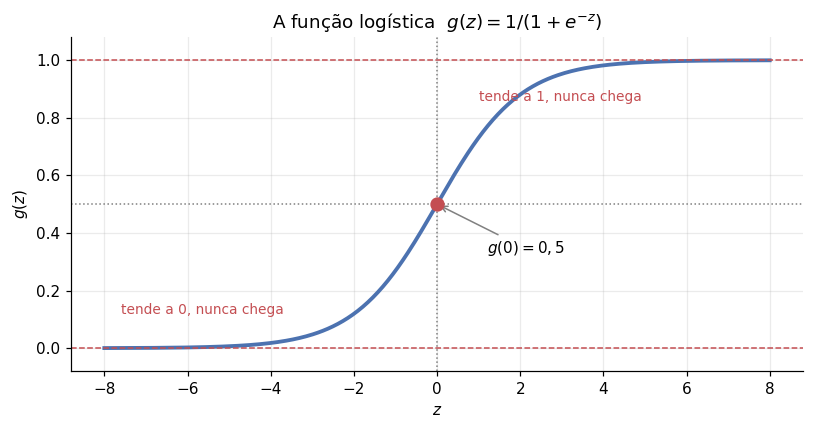

Qualquer número real entra; sai algo entre 0 e 1 - que já podemos ler como
probabilidade. Falta só decidir o que colocar no lugar de z.


In [9]:
z = np.linspace(-8, 8, 400)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(z, sigmoide(z), color=CORES[0], lw=2.5)
ax.axhline(0.5, color="gray", lw=1, ls=":")
ax.axhline(1.0, color=CORES[3], lw=1, ls="--")
ax.axhline(0.0, color=CORES[3], lw=1, ls="--")
ax.axvline(0.0, color="gray", lw=1, ls=":")
ax.scatter([0], [0.5], s=70, c=CORES[3], zorder=4)
ax.annotate("$g(0) = 0,5$", xy=(0, 0.5), xytext=(1.2, 0.33), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate("tende a 1, nunca chega", xy=(6.5, 0.9985), xytext=(1.0, 0.86),
            fontsize=9, color=CORES[3])
ax.annotate("tende a 0, nunca chega", xy=(-6.5, 0.0015), xytext=(-7.6, 0.12),
            fontsize=9, color=CORES[3])
ax.set_xlabel("$z$")
ax.set_ylabel("$g(z)$")
ax.set_ylim(-0.08, 1.08)
ax.set_title(r"A função logística  $g(z) = 1/(1 + e^{-z})$")
plt.tight_layout()
plt.show()

print("Qualquer número real entra; sai algo entre 0 e 1 - que já podemos ler como")
print("probabilidade. Falta só decidir o que colocar no lugar de z.")

---
## 4. Regressão logística: $h(x) = g(\theta^T x)$

O que entra no lugar de $z$ é **a mesma reta da aula 02**:

$$h(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

Nada mais mudou: continuamos aprendendo os mesmos $\theta_0, \theta_1, \ldots$. A
diferença é que a saída atravessa a sigmoide antes de virar resposta - e por isso
passa a ter uma leitura honesta:

$$h(x) = P(y = 1 \mid x; \theta)$$

*"Se $h(x) = 0{,}7$, interpretamos que há 70% de chance de ser comestível"*, dizem os
slides. Aqui: 70% de chance de ser Chinstrap.

No scikit-learn isso é `LogisticRegression`. A API é a mesma de sempre - `fit`,
`predict`, `score` - com um método novo e central hoje: **`predict_proba`**.

In [10]:
from sklearn.linear_model import LogisticRegression

modelo1d = LogisticRegression()      # C=1.0 e penalty='l2' são o padrão; voltamos a isso
modelo1d.fit(X1d, y)

theta0 = modelo1d.intercept_[0]
theta1 = modelo1d.coef_[0][0]

print(f"theta_0 (intercepto) = {theta0:8.4f}")
print(f"theta_1 (bico)       = {theta1:8.4f}")
print(f"\nh(x) = g({theta0:.3f} + {theta1:.3f}·x)")
print(f"\nAcurácia no treino: {modelo1d.score(X1d, y):.1%}  "
      f"({(modelo1d.predict(X1d) != y).sum()} erros em {m})")

theta_0 (intercepto) = -44.9075
theta_1 (bico)       =   1.0181

h(x) = g(-44.908 + 1.018·x)

Acurácia no treino: 95.9%  (9 erros em 219)


In [11]:
# predict_proba devolve DUAS colunas: P(y=0) e P(y=1), nessa ordem. Elas somam 1,
# como nos slides: P(y=0|x) + P(y=1|x) = 1.
exemplos = np.array([[35.0], [44.0], [46.0], [55.0]])
probas = modelo1d.predict_proba(exemplos)

tabela = pd.DataFrame({
    "bico (mm)": exemplos.ravel(),
    "P(y=0) Adélie": probas[:, 0].round(4),
    "P(y=1) Chinstrap": probas[:, 1].round(4),
    "soma": probas.sum(axis=1).round(6),
    "predição": np.where(modelo1d.predict(exemplos) == 1, "Chinstrap", "Adélie"),
})
print(tabela.to_string(index=False))
print("\nA coluna 'soma' é 1 em todas as linhas - não por acaso, mas por construção.")

 bico (mm)  P(y=0) Adélie  P(y=1) Chinstrap  soma  predição
      35.0         0.9999            0.0001   1.0    Adélie
      44.0         0.5273            0.4727   1.0    Adélie
      46.0         0.1271            0.8729   1.0 Chinstrap
      55.0         0.0000            1.0000   1.0 Chinstrap

A coluna 'soma' é 1 em todas as linhas - não por acaso, mas por construção.


### 🔨 IMPLEMENTE 2 - refazendo `predict_proba` na mão

O `predict_proba` não é mágica: é a sua `sigmoide` aplicada a $\theta^T x$. Escreva
a função que faz essa conta e confira que ela devolve **os mesmos números** do
scikit-learn.

Atenção à convenção: o scikit-learn guarda o intercepto **separado** (em
`intercept_`), enquanto a teoria usa o truque do $x_0 = 1$ para embutir $\theta_0$
no vetor. Aqui vamos fazer como a biblioteca: some o intercepto à parte.

In [12]:
def probabilidade(X, theta_0, theta_demais):
    """P(y = 1 | x) para cada linha de X, na mão.

    Parâmetros
    ----------
    X            : np.ndarray (m, n) - m exemplos, n atributos
    theta_0      : float           - o intercepto
    theta_demais : np.ndarray (n,) - um coeficiente por atributo

    Devolve
    -------
    np.ndarray (m,) com valores em (0, 1)
    """
    z = theta_0 + np.asarray(X, dtype=float) @ np.asarray(theta_demais, dtype=float)
    return sigmoide(z)

In [13]:
# Conferência da IMPLEMENTE 2: tem que bater com o scikit-learn até a última casa.
minha = probabilidade(X1d, modelo1d.intercept_[0], modelo1d.coef_[0])
dele = modelo1d.predict_proba(X1d)[:, 1]

assert minha.shape == (m,), f"esperado formato ({m},), veio {minha.shape}"
assert np.allclose(minha, dele, atol=1e-12), "as probabilidades não bateram"
assert np.allclose((minha >= 0.5).astype(int), modelo1d.predict(X1d)), \
    "predict é só a probabilidade cortada em 0,5"
print("OK - a sua conta e a do scikit-learn são a mesma conta.")
print(f"maior diferença encontrada: {np.abs(minha - dele).max():.2e}")

OK - a sua conta e a do scikit-learn são a mesma conta.
maior diferença encontrada: 2.78e-17


---
## 5. A fronteira de decisão

Agora a pergunta central da aula. O modelo prevê $y = 1$ quando $h(x) \geq 0{,}5$.
Mas $h(x) = g(\theta^T x)$, e a sigmoide vale 0,5 exatamente em $z = 0$. Como $g$ é
crescente, os slides fazem a cadeia:

$$h(x) \geq 0{,}5 \;\Longleftrightarrow\; g(z) \geq 0{,}5 \;\Longleftrightarrow\;
z \geq 0 \;\Longleftrightarrow\; \theta^T x \geq 0$$

Ou seja: **a sigmoide não decide nada**. Ela só reescala. Quem separa as classes é o
sinal de $\theta^T x$ - a mesma expressão linear da aula 02. O conjunto de pontos
onde $\theta^T x = 0$ é a **fronteira de decisão**.

Em uma dimensão, $\theta_0 + \theta_1 x = 0$ é **um ponto**:
$x = -\theta_0 / \theta_1$.

Fronteira de decisão: x = -theta_0/theta_1 = 44.11 mm
Confirmando, h(44.1075) = 0.500000


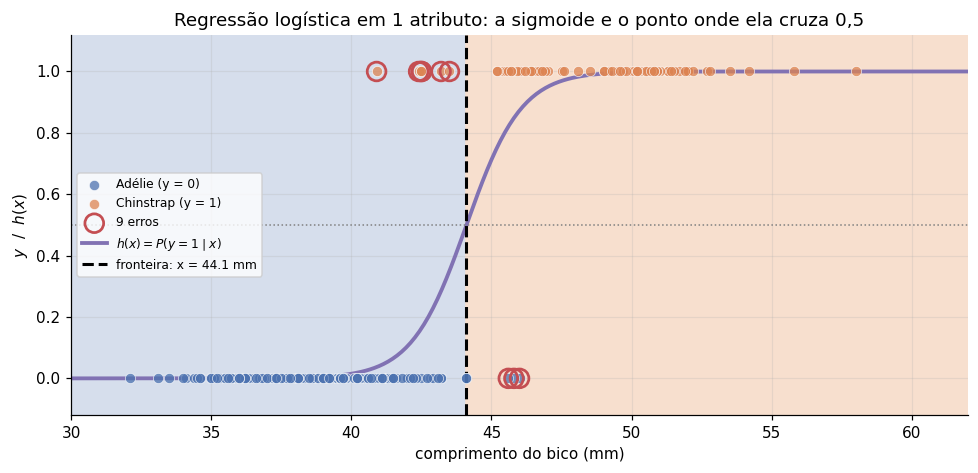

In [14]:
fronteira_1d = -theta0 / theta1
print(f"Fronteira de decisão: x = -theta_0/theta_1 = {fronteira_1d:.2f} mm")
print(f"Confirmando, h({fronteira_1d:.4f}) = "
      f"{modelo1d.predict_proba([[fronteira_1d]])[0, 1]:.6f}")

grade = np.linspace(30, 62, 400)
h_grade = modelo1d.predict_proba(grade.reshape(-1, 1))[:, 1]
erros = modelo1d.predict(X1d) != y

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.axvspan(30, fronteira_1d, color=MAPA_REGIOES(0), zorder=0)
ax.axvspan(fronteira_1d, 62, color=MAPA_REGIOES(1), zorder=0)
for classe in (0, 1):
    marca = y == classe
    ax.scatter(x1d[marca], y[marca], s=45, alpha=0.75, edgecolor="white", linewidth=0.5,
               c=CORES[0] if classe == 0 else CORES[1], label=NOMES_CLASSE[classe],
               zorder=3)
ax.scatter(x1d[erros], y[erros], s=150, facecolor="none", edgecolor=CORES[3],
           linewidth=1.8, label=f"{erros.sum()} erros", zorder=4)
ax.plot(grade, h_grade, color=CORES[4], lw=2.5, label="$h(x) = P(y=1 \\mid x)$")
ax.axhline(0.5, color="gray", lw=1, ls=":")
ax.axvline(fronteira_1d, color="black", lw=2, ls="--",
           label=f"fronteira: x = {fronteira_1d:.1f} mm")
ax.set_xlim(30, 62)
ax.set_ylim(-0.12, 1.12)
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("$y$  /  $h(x)$")
ax.set_title("Regressão logística em 1 atributo: a sigmoide e o ponto onde ela cruza 0,5")
ax.legend(fontsize=8, loc="center left")
plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: os pontos circulados de vermelho são os erros. Repare **onde**
eles estão: todos coladinhos na fronteira, na faixa em que a sigmoide está passando
de 0 para 1. Nenhum erro acontece lá nas pontas.

Isso não é coincidência, e é a diferença prática entre `predict` e `predict_proba`:
um pinguim de bico 43,8 mm e outro de 32 mm recebem os dois a resposta "Adélie", mas
com $h(x) = 0{,}42$ e $h(x) = 0{,}0000003$. **A distância até a fronteira é a
confiança do modelo** - e ela se perde quando você só olha o `predict`.

Compare com a reta da seção 2: lá, o valor previsto crescia sem limite conforme o
bico aumentava, como se um bico de 88 mm fosse "mais Chinstrap" que um de 55 mm. Na
sigmoide, passado certo ponto, a certeza satura - que é o comportamento razoável.

---
## 6. Duas dimensões: a fronteira vira uma reta

Com dois atributos, a hipótese dos slides é

$$h(x) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2)$$

e a fronteira $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$ é **uma reta** no plano
$(x_1, x_2)$. Ela divide o plano em dois semiplanos: de um lado o modelo responde 1,
do outro responde 0.

Vamos usar **comprimento** e **profundidade** do bico. Pela tabela da seção 1, a
profundidade sozinha não separa nada (18,3 contra 18,4 mm) - mas veremos que, somada
ao comprimento, ela ainda ajuda um pouco: os erros caem de 9 para 6. É o efeito de
poder **inclinar** a fronteira, em vez de deixá-la perpendicular ao eixo do comprimento.

Primeiro, a ferramenta que vai desenhar todas as fronteiras do resto da aula. A
receita é sempre a mesma: cobrir o plano com uma **grade fina** de pontos, pedir a
previsão para cada ponto da grade e pintar o resultado.

Coeficientes aprendidos:
  theta_0 (intercepto)        =  -24.5494
  theta_1 (comprimento do bico) =    1.3580
  theta_2 (profundidade do bico) =   -1.9241

Acurácia: 97.3%  (6 erros em 219)
Com um atributo só eram 9 erros.


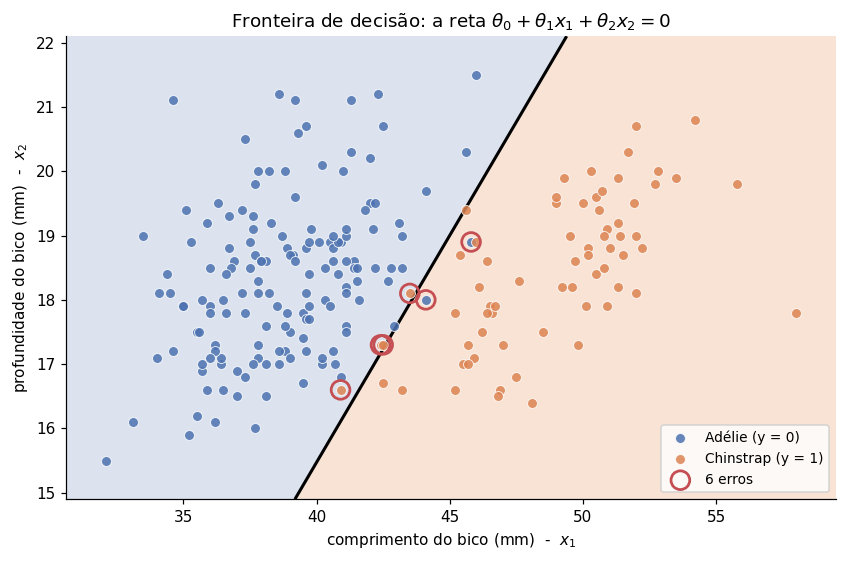

In [15]:
def plota_regioes(modelo, X, y, ax, rotulos=NOMES_CLASSE, passo=300, probabilidade=False):
    """Pinta as regiões de decisão de um modelo de 2 atributos e desenha os pontos.

    Estende os limites um pouco além dos dados, monta uma grade `passo` × `passo`,
    classifica cada célula e pinta. É assim que se enxerga a fronteira: ela é a
    linha onde a cor troca.
    """
    x_min, x_max = X[:, 0].min() - 1.5, X[:, 0].max() + 1.5
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, passo),
                         np.linspace(y_min, y_max, passo))
    grade = np.c_[xx.ravel(), yy.ravel()]        # (passo², 2) - o formato que o fit espera

    if probabilidade:
        z = modelo.predict_proba(grade)[:, 1].reshape(xx.shape)
        mapa = ax.contourf(xx, yy, z, levels=np.linspace(0, 1, 21), cmap="RdBu_r",
                           alpha=0.75)
        ax.contour(xx, yy, z, levels=[0.1, 0.3, 0.7, 0.9], colors="white",
                   linewidths=0.8, linestyles=":")
        plt.colorbar(mapa, ax=ax, label="$P(y = 1 \\mid x)$")
    else:
        z = modelo.predict(grade).reshape(xx.shape)
        ax.contourf(xx, yy, z, alpha=0.85, cmap=MAPA_REGIOES, levels=[-0.5, 0.5, 1.5])

    # A fronteira propriamente dita: onde a probabilidade é exatamente 0,5.
    z50 = modelo.predict_proba(grade)[:, 1].reshape(xx.shape)
    ax.contour(xx, yy, z50, levels=[0.5], colors="black", linewidths=2)

    for classe in (0, 1):
        marca = y == classe
        ax.scatter(X[marca, 0], X[marca, 1], s=42, alpha=0.85, edgecolor="white",
                   linewidth=0.6, c=CORES[0] if classe == 0 else CORES[1],
                   label=rotulos[classe], zorder=3)
    errados = modelo.predict(X) != y
    if errados.any():
        ax.scatter(X[errados, 0], X[errados, 1], s=150, facecolor="none",
                   edgecolor=CORES[3], linewidth=1.8, zorder=4,
                   label=f"{errados.sum()} erros")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)
    return ax


ATRIBUTOS_2D = ["bico_comprimento", "bico_profundidade"]
X2d = duas[ATRIBUTOS_2D].to_numpy(dtype=float)

modelo2d = LogisticRegression().fit(X2d, y)
print("Coeficientes aprendidos:")
print(f"  theta_0 (intercepto)        = {modelo2d.intercept_[0]:9.4f}")
print(f"  theta_1 (comprimento do bico) = {modelo2d.coef_[0][0]:9.4f}")
print(f"  theta_2 (profundidade do bico) = {modelo2d.coef_[0][1]:9.4f}")
print(f"\nAcurácia: {modelo2d.score(X2d, y):.1%}  "
      f"({(modelo2d.predict(X2d) != y).sum()} erros em {m})")
print(f"Com um atributo só eram {(modelo1d.predict(X1d) != y).sum()} erros.")

fig, ax = plt.subplots(figsize=(7.8, 5.2))
plota_regioes(modelo2d, X2d, y, ax)
ax.set_xlabel("comprimento do bico (mm)  -  $x_1$")
ax.set_ylabel("profundidade do bico (mm)  -  $x_2$")
ax.set_title("Fronteira de decisão: a reta $\\theta_0 + \\theta_1 x_1 + \\theta_2 x_2 = 0$")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### 🔨 IMPLEMENTE 3 - a equação da reta

A linha preta do gráfico foi desenhada pelo `contour`, que não sabe nada de álgebra:
ele só procurou onde a probabilidade vale 0,5 numa grade de 90 000 pontos. Mas essa
reta tem equação fechada. Isolando $x_2$ em $\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$:

$$x_2 = -\frac{\theta_0 + \theta_1 x_1}{\theta_2}$$

Implemente e confira que a sua reta cai **exatamente** sobre a linha do `contour`.

In [16]:
def fronteira_x2(theta_0, theta_1, theta_2, x1):
    """Dado x1, devolve o x2 que fica EM CIMA da fronteira de decisão.

    Devolve np.ndarray com o mesmo formato de x1.
    """
    x1 = np.asarray(x1, dtype=float)
    return -(theta_0 + theta_1 * x1) / theta_2

In [17]:
# Conferência da IMPLEMENTE 3
# (a) o exemplo do slide: theta = [-3, 1, 1] dá a reta x1 + x2 = 3
assert np.isclose(fronteira_x2(-3, 1, 1, 1.0), 2.0), "com theta=[-3,1,1] e x1=1, x2 deve ser 2"
assert np.isclose(fronteira_x2(-3, 1, 1, 0.0), 3.0), "com theta=[-3,1,1] e x1=0, x2 deve ser 3"
# (b) no nosso modelo, todo ponto da reta tem que ter probabilidade 0,5
t0, (t1, t2) = modelo2d.intercept_[0], modelo2d.coef_[0]
x1_teste = np.array([40.0, 45.0, 50.0])
pontos = np.c_[x1_teste, fronteira_x2(t0, t1, t2, x1_teste)]
assert np.allclose(modelo2d.predict_proba(pontos)[:, 1], 0.5, atol=1e-9), \
    "os pontos da sua reta deveriam ter h(x) = 0,5"
print("OK - a equação da fronteira está certa.")
print(pd.DataFrame({"x1": pontos[:, 0], "x2 na fronteira": pontos[:, 1].round(3),
                    "h(x)": modelo2d.predict_proba(pontos)[:, 1].round(6)}).to_string(index=False))

OK - a equação da fronteira está certa.
  x1  x2 na fronteira  h(x)
40.0           15.473   0.5
45.0           19.002   0.5
50.0           22.531   0.5


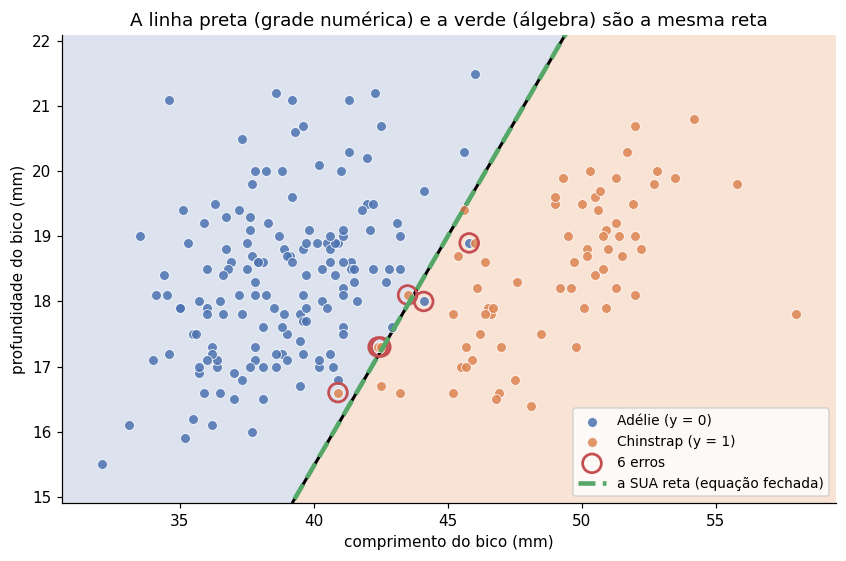

Inclinação da fronteira: +0.706 mm de profundidade por mm de comprimento
|theta_1| = 1.358   |theta_2| = 1.924

CUIDADO ao ler esses dois números: eles estão em unidades CRUAS. O comprimento
varia numa faixa de ~26 mm na base, a profundidade em ~6 mm - então coeficiente
maior pode significar apenas que o atributo se mexe menos. Para comparar
IMPORTÂNCIA é preciso padronizar os atributos primeiro, como na aula 02:
o exercício 1 faz isso, e lá o comprimento aparece ~3x mais forte.


In [18]:
# A reta calculada por você, sobreposta ao contorno numérico. Devem coincidir.
fig, ax = plt.subplots(figsize=(7.8, 5.2))
plota_regioes(modelo2d, X2d, y, ax)
grade_x1 = np.linspace(X2d[:, 0].min() - 1.5, X2d[:, 0].max() + 1.5, 100)
ax.plot(grade_x1, fronteira_x2(t0, t1, t2, grade_x1), color=CORES[2], lw=3, ls="--",
        label="a SUA reta (equação fechada)", zorder=5)
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("profundidade do bico (mm)")
ax.set_title("A linha preta (grade numérica) e a verde (álgebra) são a mesma reta")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

inclinacao = -t1 / t2
print(f"Inclinação da fronteira: {inclinacao:+.3f} mm de profundidade por mm de comprimento")
print(f"|theta_1| = {abs(t1):.3f}   |theta_2| = {abs(t2):.3f}")
print()
print("CUIDADO ao ler esses dois números: eles estão em unidades CRUAS. O comprimento")
print("varia numa faixa de ~26 mm na base, a profundidade em ~6 mm - então coeficiente")
print("maior pode significar apenas que o atributo se mexe menos. Para comparar")
print("IMPORTÂNCIA é preciso padronizar os atributos primeiro, como na aula 02:")
print("o exercício 1 faz isso, e lá o comprimento aparece ~3x mais forte.")

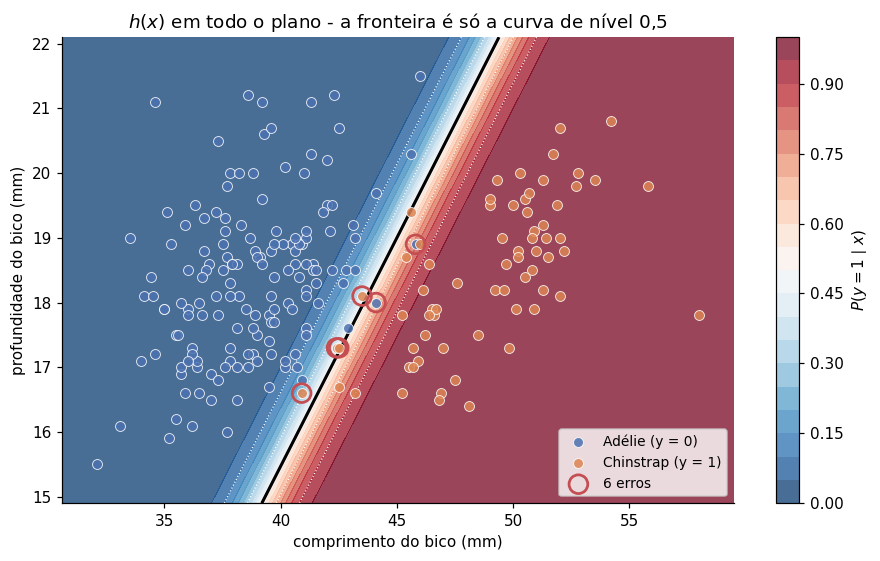

As linhas brancas pontilhadas são as curvas de nível 0,1 / 0,3 / 0,7 / 0,9.
Repare que elas são PARALELAS à fronteira e igualmente espaçadas: com um modelo
linear, a confiança cresce de forma constante conforme a gente se afasta.


In [19]:
# O mesmo modelo, mostrando a PROBABILIDADE em vez da classe. É a informação que o
# `predict` joga fora.
fig, ax = plt.subplots(figsize=(8.4, 5.2))
plota_regioes(modelo2d, X2d, y, ax, probabilidade=True)
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("profundidade do bico (mm)")
ax.set_title("$h(x)$ em todo o plano - a fronteira é só a curva de nível 0,5")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print("As linhas brancas pontilhadas são as curvas de nível 0,1 / 0,3 / 0,7 / 0,9.")
print("Repare que elas são PARALELAS à fronteira e igualmente espaçadas: com um modelo")
print("linear, a confiança cresce de forma constante conforme a gente se afasta.")

---
## 7. Escolhendo $\theta$ na mão - o exemplo dos slides

Nos slides aparece um modelo com $\theta = [-3, 1, 1]$, sem nenhum treinamento:

$$\text{prever } y = 1 \text{ se } -3 + x_1 + x_2 \geq 0
\;\Longleftrightarrow\; x_1 + x_2 \geq 3$$

Vale reproduzir isso porque separa duas coisas que costumam se confundir: **a
fronteira é uma propriedade do $\theta$**, não do algoritmo de treinamento. Dado
qualquer $\theta$, a fronteira já está determinada - treinar é só o processo de
escolher um $\theta$ bom.

Note que aqui não há `fit` nenhum: os números vêm do slide.

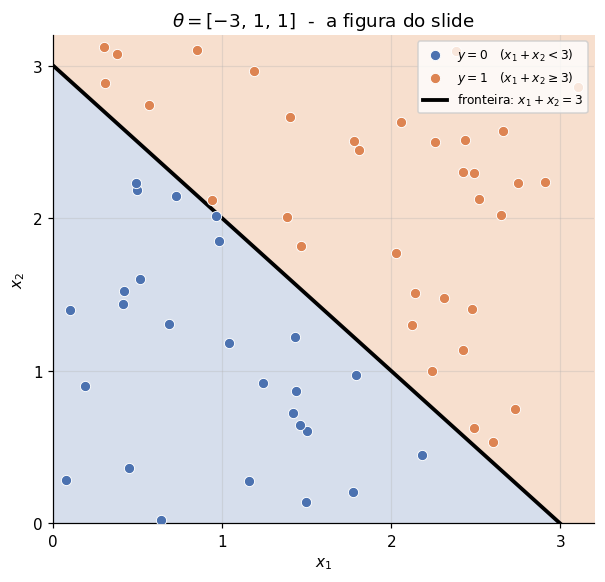

x = [1.0, 1.0]:  z = -1.0   h(x) = 0.2689   → y = 0
x = [1.5, 1.5]:  z = +0.0   h(x) = 0.5000   → y = 1
x = [3.0, 1.0]:  z = +1.0   h(x) = 0.7311   → y = 1


In [20]:
THETA_SLIDE = np.array([-3.0, 1.0, 1.0])       # [theta_0, theta_1, theta_2]

# Alguns pontos espalhados no quadrado [0, 3] × [0, 3], rotulados pela própria regra.
pontos_slide = rng.uniform(0, 3.2, size=(60, 2))
z_slide = THETA_SLIDE[0] + pontos_slide @ THETA_SLIDE[1:]
y_slide = (z_slide >= 0).astype(int)

fig, ax = plt.subplots(figsize=(5.6, 5.4))
grade_x = np.linspace(0, 3.2, 200)
ax.fill_between(grade_x, fronteira_x2(*THETA_SLIDE, grade_x), 3.2,
                color=MAPA_REGIOES(1), zorder=0)
ax.fill_between(grade_x, 0, fronteira_x2(*THETA_SLIDE, grade_x),
                color=MAPA_REGIOES(0), zorder=0)
for classe, nome in [(0, "$y = 0$   ($x_1 + x_2 < 3$)"), (1, "$y = 1$   ($x_1 + x_2 \\geq 3$)")]:
    marca = y_slide == classe
    ax.scatter(pontos_slide[marca, 0], pontos_slide[marca, 1], s=45, zorder=3,
               c=CORES[0] if classe == 0 else CORES[1], edgecolor="white",
               linewidth=0.6, label=nome)
ax.plot(grade_x, fronteira_x2(*THETA_SLIDE, grade_x), color="black", lw=2.5,
        label="fronteira: $x_1 + x_2 = 3$")
ax.set_xlim(0, 3.2)
ax.set_ylim(0, 3.2)
ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([0, 1, 2, 3])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"$\theta = [-3,\, 1,\, 1]$  -  a figura do slide")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for ponto in ([1.0, 1.0], [1.5, 1.5], [3.0, 1.0]):
    p = probabilidade(np.array([ponto]), THETA_SLIDE[0], THETA_SLIDE[1:])[0]
    lado = "y = 1" if p >= 0.5 else "y = 0"
    print(f"x = {ponto}:  z = {THETA_SLIDE[0] + sum(ponto):+.1f}   h(x) = {p:.4f}   → {lado}")

Repare no ponto $[1{,}5;\ 1{,}5]$: ele está **exatamente** sobre a fronteira,
$z = 0$, e recebe $h(x) = 0{,}5$ - o modelo está em cima do muro, como deveria.

---
## 8. Fronteiras não lineares: termos polinomiais

Toda fronteira que vimos até agora foi uma **reta**, porque $\theta^T x$ é uma
expressão linear em $x$. E quando os dados não se separam por reta nenhuma?

Os slides respondem: *"termos polinomiais tornam a borda de decisão mais complexa"*.
Acrescente $x_1^2$ e $x_2^2$ à lista de atributos:

$$h(x) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_2^2)$$

Com $\theta = [-1, 0, 0, 1, 1]$, a fronteira vira $x_1^2 + x_2^2 = 1$: **um círculo**.

O truque é que o modelo continua **linear nos parâmetros** - ele só deixou de ser
linear nos atributos originais. Quem faz esse aumento no scikit-learn é o
`PolynomialFeatures`, e a `Pipeline` da aula 02 encadeia tudo.

In [21]:
from sklearn.datasets import make_circles
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X_circ, y_circ = make_circles(n_samples=300, noise=0.12, factor=0.4,
                              random_state=RANDOM_STATE)

# (a) regressão logística "crua": só x1 e x2
so_reta = LogisticRegression().fit(X_circ, y_circ)

# (b) com termos de grau 2. include_bias=False porque o LogisticRegression já
#     tem o seu próprio intercepto (o intercept_).
com_quadrado = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(C=1e4, max_iter=5000),
).fit(X_circ, y_circ)

print(f"Só com x1 e x2:            acurácia {so_reta.score(X_circ, y_circ):.1%}")
print(f"Com x1, x2, x1², x1x2, x2²: acurácia {com_quadrado.score(X_circ, y_circ):.1%}")

nomes = com_quadrado[0].get_feature_names_out(["x1", "x2"])
coefs = com_quadrado[-1].coef_[0]
print(f"\ntheta_0 = {com_quadrado[-1].intercept_[0]:8.2f}")
for nome, c in zip(nomes, coefs):
    print(f"theta({nome:5s}) = {c:8.2f}")

Só com x1 e x2:            acurácia 48.7%
Com x1, x2, x1², x1x2, x2²: acurácia 99.3%

theta_0 =    25.92
theta(x1   ) =    -1.25
theta(x2   ) =     0.35
theta(x1^2 ) =   -44.81
theta(x1 x2) =    -6.90
theta(x2^2 ) =   -51.78


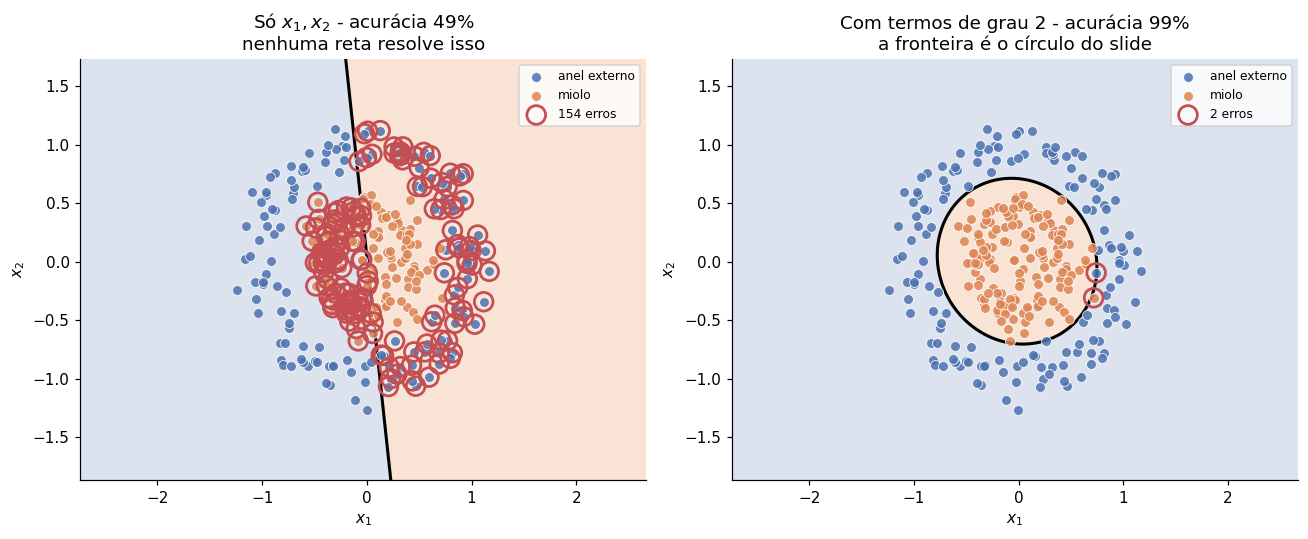

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plota_regioes(so_reta, X_circ, y_circ, axes[0], rotulos=["anel externo", "miolo"])
axes[0].set_title(f"Só $x_1, x_2$ - acurácia {so_reta.score(X_circ, y_circ):.0%}\n"
                  "nenhuma reta resolve isso")
plota_regioes(com_quadrado, X_circ, y_circ, axes[1], rotulos=["anel externo", "miolo"])
axes[1].set_title(f"Com termos de grau 2 - acurácia {com_quadrado.score(X_circ, y_circ):.0%}\n"
                  "a fronteira é o círculo do slide")
for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: olhe os coeficientes impressos acima. Os termos $x_1$, $x_2$ e
$x_1 x_2$ ficaram bem menores, enquanto $x_1^2$ e $x_2^2$ ficaram grandes e **negativos**,
com o intercepto positivo. Isto é, a regra aprendida foi mais ou menos

$$26 - 45\,x_1^2 - 52\,x_2^2 \geq 0 \;\Longleftrightarrow\; x_1^2 + x_2^2 \lesssim 0{,}55$$

que é a mesma família do slide ($-1 + x_1^2 + x_2^2 \geq 0$), com os sinais trocados
porque aqui a classe 1 é o **miolo**, e não o anel de fora. Ninguém programou "faça
um círculo": o círculo apareceu porque era o que minimizava o custo dentro do espaço
de hipóteses que oferecemos ao modelo.

---
## 9. Complexidade demais: overfitting

Se grau 2 é bom, grau 15 é melhor? Os slides já avisaram que não: *"modelos mais
complexos tendem a sofrer problemas de overfitting - alta variância"*, e do outro
lado *"modelos muito simples tendem a não se adequar aos dados - alto bias"*.

Para ver isso acontecer eu preciso de dados **mais difíceis** e **mais escassos** -
com 300 pontos limpos o grau 2 já resolve tudo. Vamos a 80 pontos bem ruidosos, e
desta vez com **conjunto de teste separado**, como na aula 01.

In [23]:
from sklearn.model_selection import train_test_split

X_ruido, y_ruido = make_circles(n_samples=80, noise=0.28, factor=0.45, random_state=7)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ruido, y_ruido, test_size=0.4, random_state=RANDOM_STATE, stratify=y_ruido)
print(f"treino: {len(y_tr)} exemplos    teste: {len(y_te)} exemplos")


def pipeline_polinomial(grau):
    """Regressão logística com termos até `grau`, praticamente sem regularização.

    O StandardScaler no meio não é firula: x^14 gera números de escalas muito
    diferentes e o otimizador não converge sem padronizar. C alto = pouca
    regularização - queremos deixar o overfitting APARECER.
    """
    return Pipeline([
        ("polinomio", PolynomialFeatures(degree=grau, include_bias=False)),
        ("escala", StandardScaler()),
        ("logistica", LogisticRegression(C=1e6, max_iter=50000)),
    ])


GRAUS = [1, 2, 3, 6, 10, 14]
linhas = []
modelos = {}
for grau in GRAUS:
    mod = pipeline_polinomial(grau).fit(X_tr, y_tr)
    modelos[grau] = mod
    linhas.append({
        "grau": grau,
        "nº de termos": mod["polinomio"].n_output_features_,
        "acurácia treino": mod.score(X_tr, y_tr),
        "acurácia teste": mod.score(X_te, y_te),
    })

resumo = pd.DataFrame(linhas)
print(resumo.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

treino: 48 exemplos    teste: 32 exemplos
 grau  nº de termos  acurácia treino  acurácia teste
    1             2            0.583           0.469
    2             5            0.750           0.906
    3             9            0.771           0.875
    6            27            1.000           0.781
   10            65            1.000           0.781
   14           119            1.000           0.781


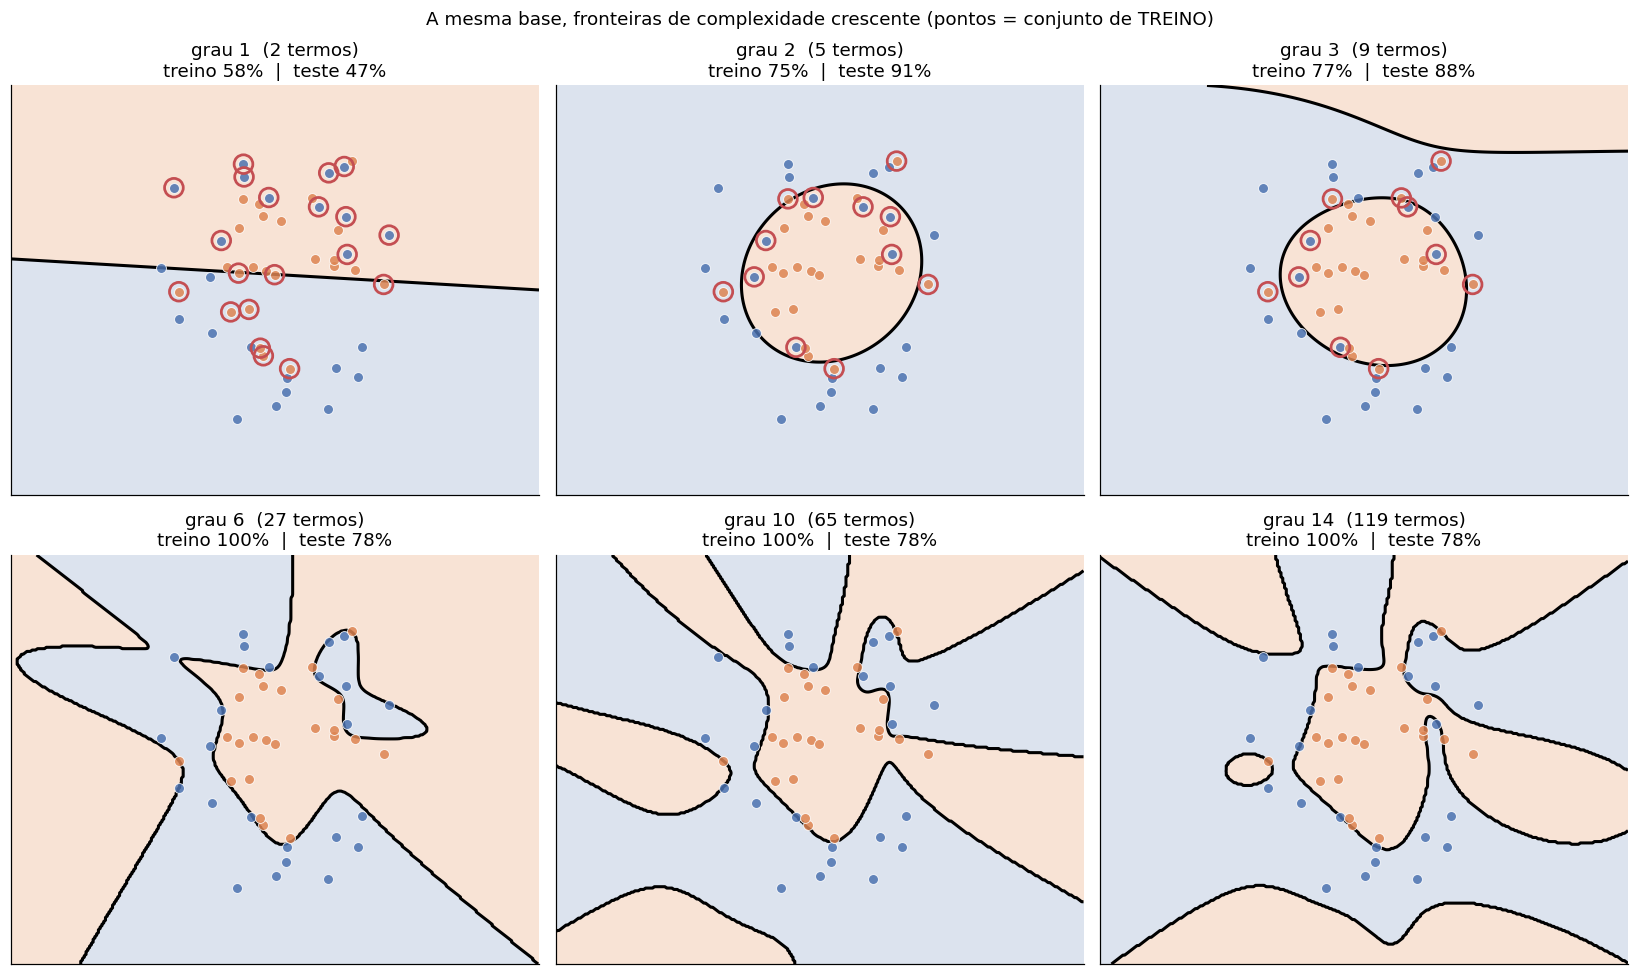

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, grau in zip(axes.ravel(), GRAUS):
    mod = modelos[grau]
    plota_regioes(mod, X_tr, y_tr, ax, rotulos=["classe 0", "classe 1"])
    ax.set_title(f"grau {grau}  ({mod['polinomio'].n_output_features_} termos)\n"
                 f"treino {mod.score(X_tr, y_tr):.0%}  |  teste {mod.score(X_te, y_te):.0%}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("A mesma base, fronteiras de complexidade crescente "
             "(pontos = conjunto de TREINO)", fontsize=12)
plt.tight_layout()
plt.show()

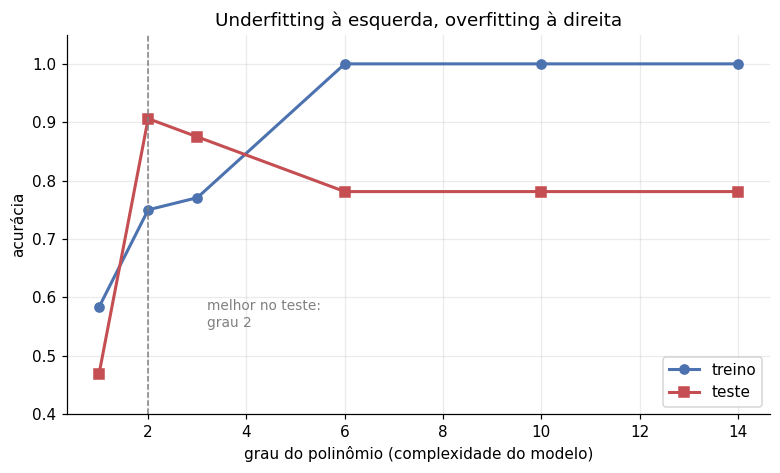

Grau 1: erra no treino E no teste - underfitting, alto bias.
Grau 6 em diante: 100% no treino e cai no teste - overfitting, alta variância.

Navalha de Ockham (slide 12): entre os modelos que se ajustam bem aos dados,
prefira o mais simples. Aqui, o grau 2.


In [25]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(resumo["grau"], resumo["acurácia treino"], "o-", color=CORES[0], lw=2,
        label="treino")
ax.plot(resumo["grau"], resumo["acurácia teste"], "s-", color=CORES[3], lw=2,
        label="teste")
melhor = resumo.loc[resumo["acurácia teste"].idxmax(), "grau"]
ax.axvline(melhor, color="gray", ls="--", lw=1)
ax.annotate(f"melhor no teste:\ngrau {melhor}", xy=(melhor, 0.55), fontsize=9,
            xytext=(melhor + 1.2, 0.55), color="gray")
ax.set_xlabel("grau do polinômio (complexidade do modelo)")
ax.set_ylabel("acurácia")
ax.set_ylim(0.4, 1.05)
ax.set_title("Underfitting à esquerda, overfitting à direita")
ax.legend()
plt.tight_layout()
plt.show()

print("Grau 1: erra no treino E no teste - underfitting, alto bias.")
print("Grau 6 em diante: 100% no treino e cai no teste - overfitting, alta variância.")
print("\nNavalha de Ockham (slide 12): entre os modelos que se ajustam bem aos dados,")
print("prefira o mais simples. Aqui, o grau 2.")

---
## 10. O limiar não precisa ser 0,5

Voltamos aos pinguins. Até aqui usamos $h(x) \geq 0{,}5$ porque é o padrão - e é o
que os slides usam. Mas 0,5 é uma **escolha**, não uma lei: nada impede prever $y=1$
a partir de $h(x) \geq 0{,}3$ ou $h(x) \geq 0{,}8$.

Isso já apareceu na aula 01, quando discutimos que a métrica depende do domínio.
Aqui há um detalhe geométrico bonito: como $h(x) = g(\theta^T x)$ e $g$ é crescente,

$$h(x) \geq t \;\Longleftrightarrow\; \theta^T x \geq g^{-1}(t)
= \ln\!\left(\frac{t}{1-t}\right)$$

ou seja, **mudar o limiar desloca a fronteira paralelamente a si mesma**. A
inclinação é do $\theta$; o limiar só escolhe qual das retas paralelas usar.

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score

probas2d = modelo2d.predict_proba(X2d)[:, 1]
LIMIARES = [0.2, 0.35, 0.5, 0.65, 0.8]

linhas = []
for t in LIMIARES:
    pred = (probas2d >= t).astype(int)
    vn, fp, fn, vp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    linhas.append({
        "limiar": t,
        "logit do limiar": np.log(t / (1 - t)),
        "VP": vp, "FN": fn, "FP": fp, "VN": vn,
        "acurácia": (pred == y).mean(),
        "precisão": precision_score(y, pred, zero_division=0),
        "revocação": recall_score(y, pred, zero_division=0),
    })
tabela_limiar = pd.DataFrame(linhas)
print(tabela_limiar.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nVP = Chinstrap identificado    FN = Chinstrap perdido")
print("FP = Adélie chamado de Chinstrap    VN = Adélie identificado")

 limiar  logit do limiar  VP  FN  FP  VN  acurácia  precisão  revocação
  0.200           -1.386  68   0   4 147     0.982     0.944      1.000
  0.350           -0.619  67   1   3 148     0.982     0.957      0.985
  0.500            0.000  64   4   2 149     0.973     0.970      0.941
  0.650            0.619  63   5   2 149     0.968     0.969      0.926
  0.800            1.386  61   7   0 151     0.968     1.000      0.897

VP = Chinstrap identificado    FN = Chinstrap perdido
FP = Adélie chamado de Chinstrap    VN = Adélie identificado


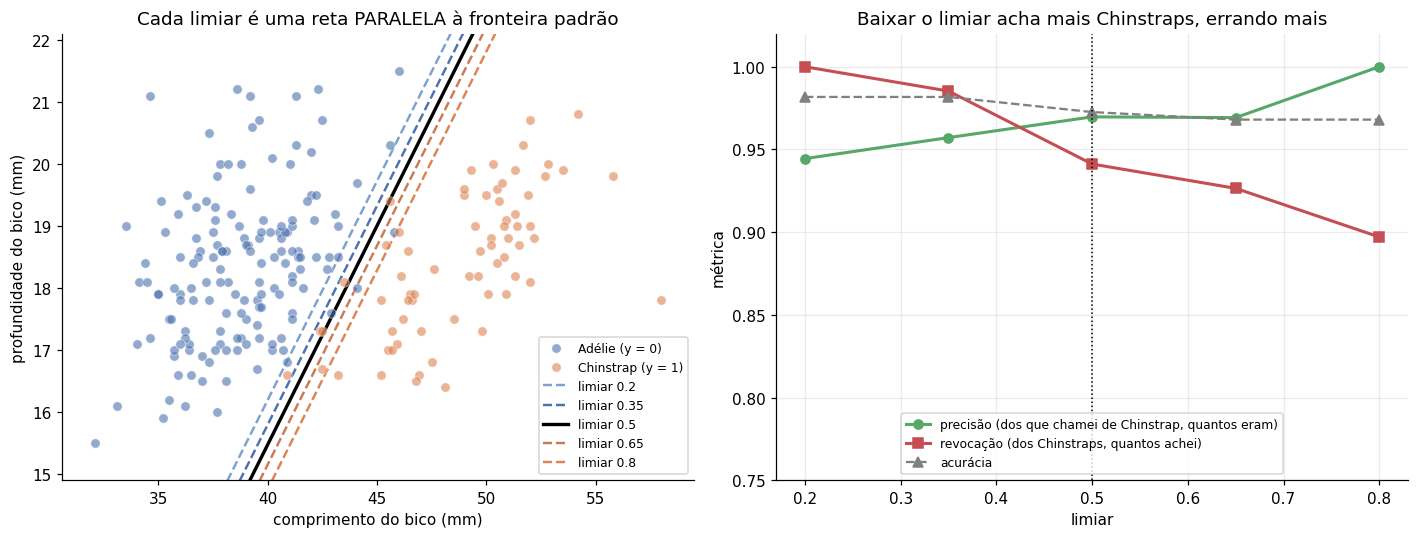

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# À esquerda: as fronteiras paralelas de cada limiar.
ax = axes[0]
x_min, x_max = X2d[:, 0].min() - 1.5, X2d[:, 0].max() + 1.5
for classe in (0, 1):
    marca = y == classe
    ax.scatter(X2d[marca, 0], X2d[marca, 1], s=38, alpha=0.6, edgecolor="white",
               linewidth=0.5, c=CORES[0] if classe == 0 else CORES[1],
               label=NOMES_CLASSE[classe], zorder=3)
grade_x1 = np.linspace(x_min, x_max, 100)
for t, cor in zip(LIMIARES, ["#7EA1D0", "#4C72B0", "black", "#C97B54", "#DD8452"]):
    logit = np.log(t / (1 - t))
    # theta_0 + theta_1 x1 + theta_2 x2 = logit  →  isola x2
    x2_linha = fronteira_x2(t0 - logit, t1, t2, grade_x1)
    ax.plot(grade_x1, x2_linha, color=cor, lw=2.2 if t == 0.5 else 1.6,
            ls="-" if t == 0.5 else "--", label=f"limiar {t}")
ax.set_xlim(x_min, x_max)
ax.set_ylim(X2d[:, 1].min() - 0.6, X2d[:, 1].max() + 0.6)
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("profundidade do bico (mm)")
ax.set_title("Cada limiar é uma reta PARALELA à fronteira padrão")
ax.legend(fontsize=8, loc="lower right")
ax.grid(False)

# À direita: o custo da escolha.
ax = axes[1]
ax.plot(tabela_limiar["limiar"], tabela_limiar["precisão"], "o-", color=CORES[2],
        lw=2, label="precisão (dos que chamei de Chinstrap, quantos eram)")
ax.plot(tabela_limiar["limiar"], tabela_limiar["revocação"], "s-", color=CORES[3],
        lw=2, label="revocação (dos Chinstraps, quantos achei)")
ax.plot(tabela_limiar["limiar"], tabela_limiar["acurácia"], "^--", color="gray",
        lw=1.5, label="acurácia")
ax.axvline(0.5, color="black", lw=1, ls=":")
ax.set_xlabel("limiar")
ax.set_ylabel("métrica")
ax.set_ylim(0.75, 1.02)
ax.set_title("Baixar o limiar acha mais Chinstraps, errando mais")
ax.legend(fontsize=8, loc="lower center")

plt.tight_layout()
plt.show()

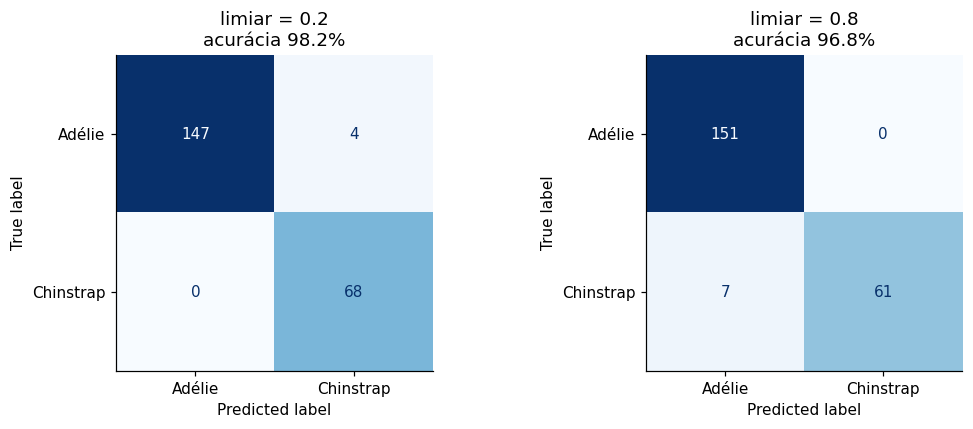

Com limiar 0,2 o modelo é 'generoso' com a classe 1: perde pouquíssimo
Chinstrap (FN baixo) mas rotula Adélies errado (FP alto). Com 0,8, o contrário.


In [28]:
# As duas matrizes de confusão extremas, lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, [0.2, 0.8]):
    pred = (probas2d >= t).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y, pred, labels=[0, 1]),
        display_labels=["Adélie", "Chinstrap"],
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"limiar = {t}\nacurácia {(pred == y).mean():.1%}")
    ax.grid(False)
plt.tight_layout()
plt.show()

print("Com limiar 0,2 o modelo é 'generoso' com a classe 1: perde pouquíssimo")
print("Chinstrap (FN baixo) mas rotula Adélies errado (FP alto). Com 0,8, o contrário.")

🔎 **PARE E PENSE**: imagine duas situações reais.

1. Uma equipe de campo quer **anilhar todos os Chinstraps** da colônia; capturar um
   Adélie por engano custa cinco minutos de trabalho.
2. Um estudo genético caro vai sequenciar apenas os pinguins classificados como
   Chinstrap, a US$ 400 por amostra.

Em qual delas você baixaria o limiar, e em qual subiria? E qual é o limiar em que
você prefere **não decidir** e mandar o bicho para um especialista?

---
## 11. Mais de duas classes

Toda a teoria de hoje foi construída para $y \in \{0, 1\}$. E as três espécies de
pinguim?

O `LogisticRegression` resolve isso sozinho: com mais de duas classes ele usa a
**regressão logística multinomial** (também chamada de *softmax*), que generaliza a
sigmoide para $K$ saídas que somam 1. Aqui isso entra como **caixa-preta** - o que
nos interessa é o efeito geométrico: em vez de uma reta, o plano fica dividido em
**três regiões**, e as fronteiras entre elas continuam sendo retas.

In [29]:
X3 = pinguins[ATRIBUTOS_2D].to_numpy(dtype=float)
especies = ["Adelie", "Chinstrap", "Gentoo"]
y3 = pinguins["especie"].map({e: i for i, e in enumerate(especies)}).to_numpy()

modelo3 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X3, y3)
print(f"Acurácia nas 3 espécies: {modelo3.score(X3, y3):.1%}  "
      f"({(modelo3.predict(X3) != y3).sum()} erros em {len(y3)})")
print(f"\nO coef_ agora tem formato {modelo3[-1].coef_.shape}: "
      "uma linha de parâmetros por classe.")

proba3 = modelo3.predict_proba(X3[:4])
print("\nAs 4 primeiras probabilidades (as três colunas somam 1):")
print(pd.DataFrame(proba3.round(4), columns=especies).assign(
    soma=proba3.sum(axis=1).round(6)).to_string(index=False))

Acurácia nas 3 espécies: 95.9%  (14 erros em 342)

O coef_ agora tem formato (3, 2): uma linha de parâmetros por classe.

As 4 primeiras probabilidades (as três colunas somam 1):
 Adelie  Chinstrap  Gentoo  soma
 0.9881     0.0119  0.0000   1.0
 0.9541     0.0431  0.0028   1.0
 0.9487     0.0502  0.0011   1.0
 0.9988     0.0012  0.0000   1.0


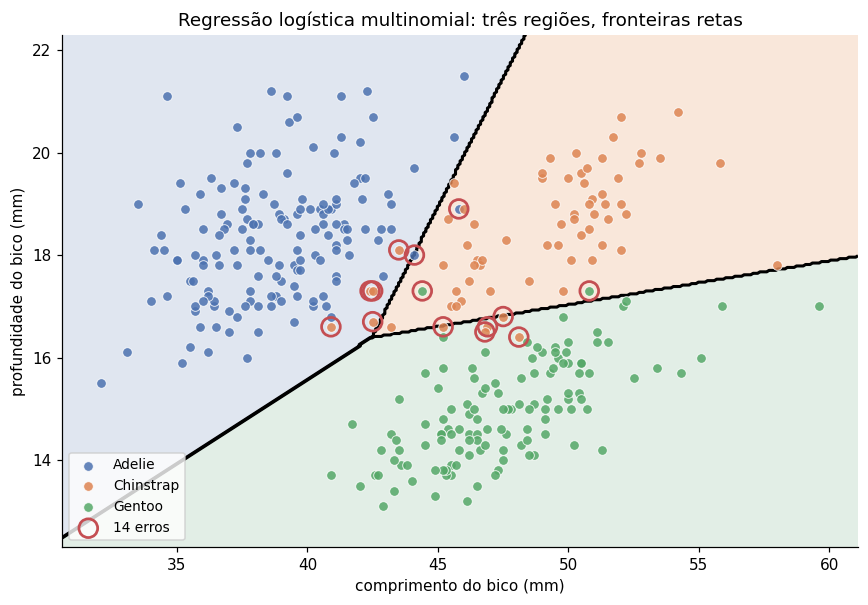

Duas medidas de um bico bastam para separar três espécies com ~96% de acerto.
Repare que Gentoo (bico raso) se separa das outras duas quase sem sobreposição;
os erros se concentram, de novo, EM CIMA das fronteiras.


In [30]:
xx, yy = np.meshgrid(np.linspace(X3[:, 0].min() - 1.5, X3[:, 0].max() + 1.5, 350),
                     np.linspace(X3[:, 1].min() - 0.8, X3[:, 1].max() + 0.8, 350))
z = modelo3.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 5.6))
ax.contourf(xx, yy, z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.75,
            colors=["#D6DEEC", "#F7DFCE", "#D9E9DE"])
ax.contour(xx, yy, z, levels=[0.5, 1.5], colors="black", linewidths=2)
for i, (esp, cor) in enumerate(zip(especies, [CORES[0], CORES[1], CORES[2]])):
    marca = y3 == i
    ax.scatter(X3[marca, 0], X3[marca, 1], s=40, c=cor, alpha=0.85,
               edgecolor="white", linewidth=0.6, label=esp, zorder=3)
errados3 = modelo3.predict(X3) != y3
ax.scatter(X3[errados3, 0], X3[errados3, 1], s=150, facecolor="none",
           edgecolor=CORES[3], linewidth=1.8, zorder=4,
           label=f"{errados3.sum()} erros")
ax.set_xlabel("comprimento do bico (mm)")
ax.set_ylabel("profundidade do bico (mm)")
ax.set_title("Regressão logística multinomial: três regiões, fronteiras retas")
ax.legend(fontsize=9, loc="lower left")
ax.grid(False)
plt.tight_layout()
plt.show()

print("Duas medidas de um bico bastam para separar três espécies com ~96% de acerto.")
print("Repare que Gentoo (bico raso) se separa das outras duas quase sem sobreposição;")
print("os erros se concentram, de novo, EM CIMA das fronteiras.")

---
## Resumo

| Ideia | Fórmula | O que significa |
|---|---|---|
| Hipótese | $h(x) = g(\theta^T x)$ | a reta da aula 02, espremida em $(0,1)$ |
| Função logística | $g(z) = \dfrac{1}{1+e^{-z}}$ | nunca chega a 0 nem a 1 |
| Leitura | $h(x) = P(y=1 \mid x; \theta)$ | a saída é probabilidade, não classe |
| Decisão | $y = 1$ se $h(x) \geq 0{,}5$ | equivale a $\theta^T x \geq 0$ |
| Fronteira | $\theta^T x = 0$ | reta (ou plano); **quem decide é o sinal de $z$** |
| Não linear | $\theta^T x$ com $x_1^2, x_2^2, \ldots$ | círculos, elipses, formas quaisquer |
| Custo | $J(\theta) = -\frac{1}{m}\sum y\log h(x) + (1-y)\log(1-h(x))$ | convexo, ao contrário do erro quadrático |

### O que ficou de fora, de propósito

- **A função de custo e o gradiente descendente.** Os slides derivam
  $J(\theta)$ e mostram que o passo de atualização é *quase idêntico* ao da regressão
  linear - só muda o $h(x)$. Hoje quem minimizou $J$ foi o scikit-learn; na próxima
  aula prática **nós** vamos escrever esse laço, como fizemos na aula 02.
- **Por que o erro quadrático não serve.** O slide 14 mostra que
  $J(\theta)$ com $\frac{1}{2}(h(x)-y)^2$ e $h$ sigmoide fica **não convexa**, cheia
  de mínimos locais. A entropia cruzada conserta isso.
- **Regularização.** O parâmetro `C` do `LogisticRegression` apareceu duas vezes
  (`C=1e4`, `C=1e6`) sem explicação. Ele controla o quanto o modelo é penalizado por
  coeficientes grandes - o antídoto para o overfitting da seção 9, e tema de uma aula
  futura.

---
# Exercícios

Os três exercícios já vêm com o **código pronto**. O trabalho é rodar, **ler os
resultados** e responder às perguntas nas células de markdown - com frases, não com
números soltos.

## Exercício 1 - a escolha dos atributos muda a fronteira

A seção 6 usou comprimento e profundidade do bico. Rode o código abaixo, que testa
**todos os pares** de medidas para o mesmo problema Adélie × Chinstrap, e depois
desenha a fronteira dos dois pares extremos.

In [31]:
import itertools

MEDIDAS = {
    "bico_comprimento": "comprimento do bico (mm)",
    "bico_profundidade": "profundidade do bico (mm)",
    "nadadeira": "comprimento da nadadeira (mm)",
    "massa_g": "massa corporal (g)",
}

resultados = []
for c1, c2 in itertools.combinations(MEDIDAS, 2):
    Xp = duas[[c1, c2]].to_numpy(dtype=float)
    # StandardScaler aqui porque massa (gramas, ~3700) e bico (mm, ~40) vivem em
    # escalas muito diferentes - o mesmo cuidado da aula 02.
    mod = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xp, y)
    resultados.append({
        "atributo 1": c1, "atributo 2": c2,
        "erros": int((mod.predict(Xp) != y).sum()),
        "acurácia": mod.score(Xp, y),
        "|theta_1|": abs(mod[-1].coef_[0][0]),
        "|theta_2|": abs(mod[-1].coef_[0][1]),
    })

ranking = pd.DataFrame(resultados).sort_values("erros").reset_index(drop=True)
print(ranking.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\n(|theta| é medido nos atributos JÁ PADRONIZADOS, por isso dá para comparar.)")

       atributo 1        atributo 2  erros  acurácia  |theta_1|  |theta_2|
 bico_comprimento           massa_g      4     0.982      4.194      1.259
 bico_comprimento bico_profundidade      7     0.968      4.174      1.293
 bico_comprimento         nadadeira      9     0.959      3.994      0.448
bico_profundidade         nadadeira     55     0.749      0.322      1.046
        nadadeira           massa_g     55     0.749      1.185      0.496
bico_profundidade           massa_g     68     0.689      0.030      0.056

(|theta| é medido nos atributos JÁ PADRONIZADOS, por isso dá para comparar.)


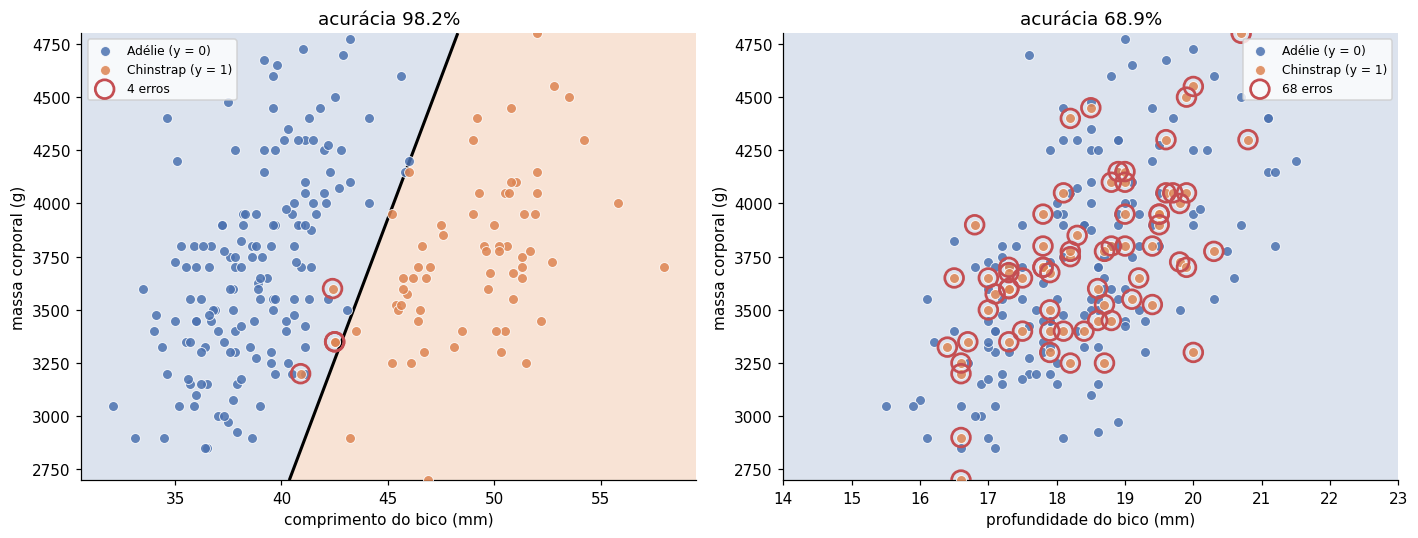

In [32]:
melhor_par = list(ranking.iloc[0][["atributo 1", "atributo 2"]])
pior_par = list(ranking.iloc[-1][["atributo 1", "atributo 2"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, par in zip(axes, [melhor_par, pior_par]):
    Xp = duas[par].to_numpy(dtype=float)
    mod = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xp, y)
    plota_regioes(mod, Xp, y, ax)
    ax.set_xlabel(MEDIDAS[par[0]])
    ax.set_ylabel(MEDIDAS[par[1]])
    ax.set_title(f"acurácia {mod.score(Xp, y):.1%}")
    ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

**Responda:**

a) Qual par de medidas separa melhor as duas espécies? Isso é coerente com a tabela
   de médias da seção 1?

b) No pior par, a acurácia ainda é bem melhor que zero. Compare com o **erro do
   classificador majoritário** que imprimimos na seção 1: o modelo aprendeu alguma
   coisa ou está só chutando a classe mais comum?

c) Olhe as colunas `|theta_1|` e `|theta_2|` do par com mais erros. O que coeficientes
   **ambos pequenos** dizem sobre a utilidade daquelas duas medidas para este problema?

d) No gráfico da direita, os pontos das duas classes estão misturados. Existe alguma
   **reta** que separaria melhor esses dados? E alguma **curva**?

🎯 **Conclusão do Exercício 1**

a) O melhor par é **comprimento do bico + massa corporal** (4 erros, 98,2%), seguido
   de perto pelo par que usamos na aula. Todos os pares campeões incluem o
   **comprimento do bico** - exatamente a medida em que as médias das duas espécies
   mais diferem (38,8 contra 48,8 mm). Coerente.

b) O par pior (profundidade + massa) erra 68 de 219, ou seja, acerta 69%. O
   classificador majoritário acertaria 68,9% (chutando "Adélie" sempre). Então o
   modelo **não aprendeu praticamente nada**: sem o comprimento do bico, essas duas
   espécies são quase indistinguíveis. É a lição de sempre - acurácia só significa
   alguma coisa quando comparada a uma linha de base.

c) Coeficientes pequenos nos **dois** atributos padronizados significam que mexer em
   qualquer um deles quase não muda $\theta^T x$, logo quase não muda a probabilidade.
   O modelo, na prática, está respondendo o mesmo para todo mundo - e o "mesmo" acaba
   sendo a classe majoritária.

d) Não: as duas nuvens estão sobrepostas, e nenhuma reta resolve. Uma curva também
   não resolveria de verdade - o problema não é o **formato** da fronteira, é que os
   dois grupos ocupam a **mesma região** do plano. Nenhuma fronteira separa pontos
   que estão em cima uns dos outros; o que falta é informação, e não flexibilidade
   do modelo. Compare com a seção 8, onde as classes ocupavam regiões distintas e só
   faltava a forma certa.

## Exercício 2 - AND, OR e XOR

Este é o exercício proposto no fim dos slides (adaptado: lá se pede a implementação
do gradiente descendente, que faremos na próxima aula prática; aqui usamos o
scikit-learn e olhamos a **fronteira**).

As três funções lógicas têm os mesmos quatro pontos de entrada -
$(0,0), (0,1), (1,0), (1,1)$ - e só o rótulo muda.

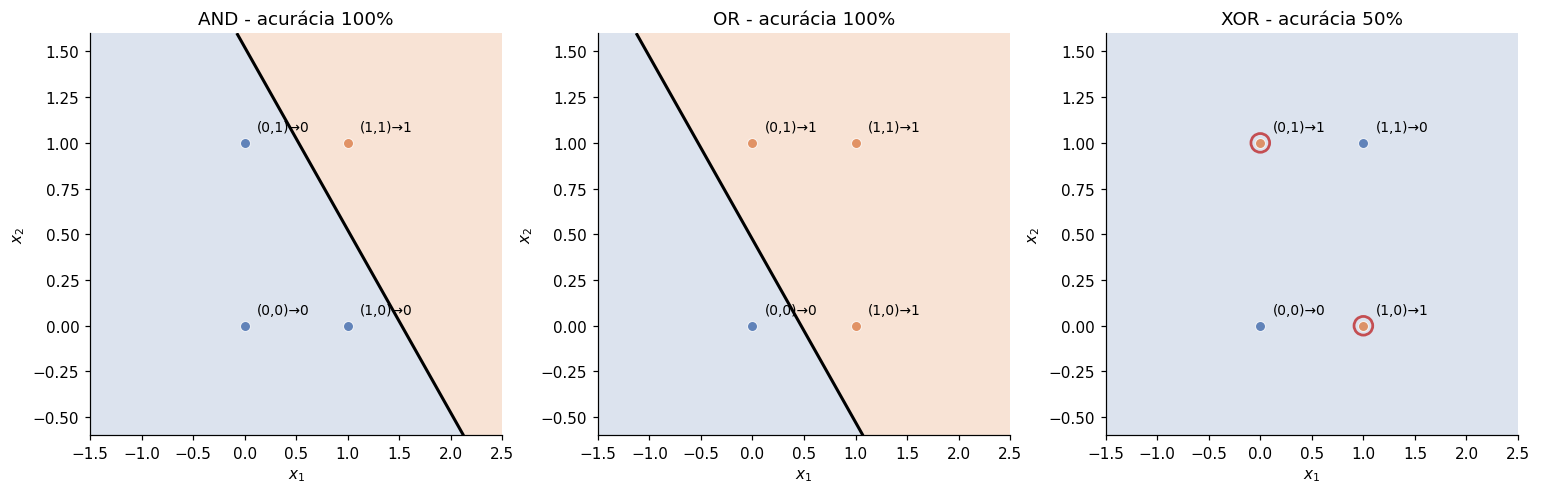

AND   acurácia 100%   previsto [0 0 0 1]  esperado [0 0 0 1]
OR    acurácia 100%   previsto [0 1 1 1]  esperado [0 1 1 1]
XOR   acurácia 50%   previsto [0 0 0 0]  esperado [0 1 1 0]


In [33]:
X_logica = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
ALVOS = {
    "AND": np.array([0, 0, 0, 1]),
    "OR":  np.array([0, 1, 1, 1]),
    "XOR": np.array([0, 1, 1, 0]),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, (nome, alvo) in zip(axes, ALVOS.items()):
    mod = LogisticRegression(C=1e4, max_iter=10000).fit(X_logica, alvo)
    plota_regioes(mod, X_logica, alvo, ax, rotulos=["saída 0", "saída 1"], passo=200)
    for (a, b), rot in zip(X_logica, alvo):
        ax.annotate(f"({a:.0f},{b:.0f})→{rot}", (a, b), textcoords="offset points",
                    xytext=(8, 8), fontsize=9)
    ax.set_title(f"{nome} - acurácia {mod.score(X_logica, alvo):.0%}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

for nome, alvo in ALVOS.items():
    mod = LogisticRegression(C=1e4, max_iter=10000).fit(X_logica, alvo)
    print(f"{nome:4s}  acurácia {mod.score(X_logica, alvo):.0%}   "
          f"previsto {mod.predict(X_logica)}  esperado {alvo}")

XOR com termos de grau 2: acurácia 100%

theta_0 =   -5.60
theta(x1   ) =    5.72
theta(x2   ) =    5.72
theta(x1^2 ) =    5.72
theta(x1 x2) =  -23.37
theta(x2^2 ) =    5.72


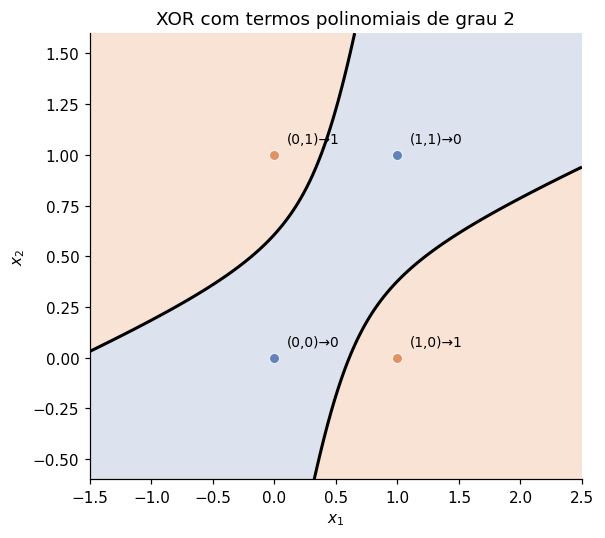

In [34]:
# O mesmo XOR, agora com termos polinomiais de grau 2 (que trazem o produto x1·x2).
xor = ALVOS["XOR"]
xor_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LogisticRegression(C=1e4, max_iter=10000),
).fit(X_logica, xor)

nomes = xor_poly[0].get_feature_names_out(["x1", "x2"])
print(f"XOR com termos de grau 2: acurácia {xor_poly.score(X_logica, xor):.0%}")
print(f"\ntheta_0 = {xor_poly[-1].intercept_[0]:7.2f}")
for nome, c in zip(nomes, xor_poly[-1].coef_[0]):
    print(f"theta({nome:5s}) = {c:7.2f}")

fig, ax = plt.subplots(figsize=(5.6, 5))
plota_regioes(xor_poly, X_logica, xor, ax, rotulos=["saída 0", "saída 1"], passo=200)
for (a, b), rot in zip(X_logica, xor):
    ax.annotate(f"({a:.0f},{b:.0f})→{rot}", (a, b), textcoords="offset points",
                xytext=(8, 8), fontsize=9)
ax.set_title("XOR com termos polinomiais de grau 2")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

**Responda:**

a) Quais das três funções a regressão logística "crua" resolve, e qual ela não
   resolve? Olhando os quatro pontos no plano, **por que** essa é impossível?

b) Que atributo novo o `PolynomialFeatures(2)` acrescentou e que faz o XOR funcionar?
   Escreva a regra aprendida (use os coeficientes impressos) e verifique nos 4 pontos.

c) Este exercício é historicamente célebre: em 1969, Minsky e Papert usaram
   exatamente o XOR para mostrar um limite do *perceptron*. Relacione o que você viu
   aqui com a seção 8 da aula.

d) A acurácia de 100% no XOR polinomial foi medida **nos mesmos 4 pontos** usados
   para treinar. Isso te preocupa? Por quê?

🎯 **Conclusão do Exercício 2**

a) AND e OR saem com 100%; o **XOR** fica em 50% (ou 75%, dependendo do ponto de
   parada do otimizador) - nunca melhor. No plano, os dois pontos de saída 1 do XOR
   são $(0,1)$ e $(1,0)$: eles estão em **cantos opostos** do quadrado, com os dois
   pontos de saída 0 nos outros dois cantos, também opostos. Qualquer reta que deixe
   $(0,1)$ e $(1,0)$ do mesmo lado obrigatoriamente deixa $(0,0)$ ou $(1,1)$ junto.
   O XOR não é **linearmente separável**, e a fronteira da regressão logística é
   sempre uma reta.

b) O termo **$x_1 x_2$** (o produto). Com ele, a regra aprendida é da forma
   $\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1 x_2 \geq 0$ com o
   coeficiente do produto grande e negativo: o produto só vale 1 no ponto $(1,1)$, e
   é justamente ele que precisa ser "puxado de volta" para a classe 0. (Repare que
   $\theta$ dos termos $x_1^2$ e $x_2^2$ saiu igual ao dos lineares: com entradas
   0/1 vale $x^2 = x$, então esses dois termos são cópias e o otimizador reparte o
   peso entre eles.) Conferindo:
   em $(0,0)$ tudo zera e sobra $\theta_0 < 0$ → classe 0; em $(0,1)$ e $(1,0)$ entra
   um dos termos lineares positivos → classe 1; em $(1,1)$ entram os dois lineares
   **mais** o produto negativo, que devolve o resultado para baixo de zero → classe 0.

c) É o mesmo fenômeno da seção 8. A regressão logística (como o perceptron) só traça
   retas **nos atributos que você der a ela**. A resposta de 1969 e a resposta de
   hoje são a mesma: mude o espaço de atributos. Acrescentar $x_1^2, x_2^2, x_1 x_2$
   transformou o círculo da seção 8 e o XOR daqui em problemas linearmente separáveis
   - só que num espaço de dimensão maior. (A outra saída histórica foi empilhar
   camadas: as redes neurais, mais adiante no curso.)

d) Deveria preocupar em geral - é medir no treino, e a seção 9 mostrou aonde isso
   leva. Neste caso específico, porém, os 4 pontos são **todo** o domínio da função:
   não existe um quinto exemplo possível de XOR sobre entradas binárias. Aqui,
   excepcionalmente, decorar é o mesmo que generalizar. O que não vale é transportar
   essa tranquilidade para bases de dados de verdade.

## Exercício 3 - de volta aos pacientes

Na aula 01 usamos a base **Heart Disease** (303 pacientes da Cleveland Clinic) com
algoritmos de caixa-preta. Agora temos um modelo que sabemos explicar - e que entrega
**probabilidade**, que é o que um médico realmente quer.

O código abaixo treina uma regressão logística com dois atributos (para podermos
desenhar a fronteira), separando treino e teste.

303 pacientes    45.9% com doença
Acurácia no treino: 68.9%
Acurácia no teste:  68.1%
Erro do majoritário: 45.9%

theta(idade padronizada)         = +0.243
theta(freq_card_max padronizada) = -0.915


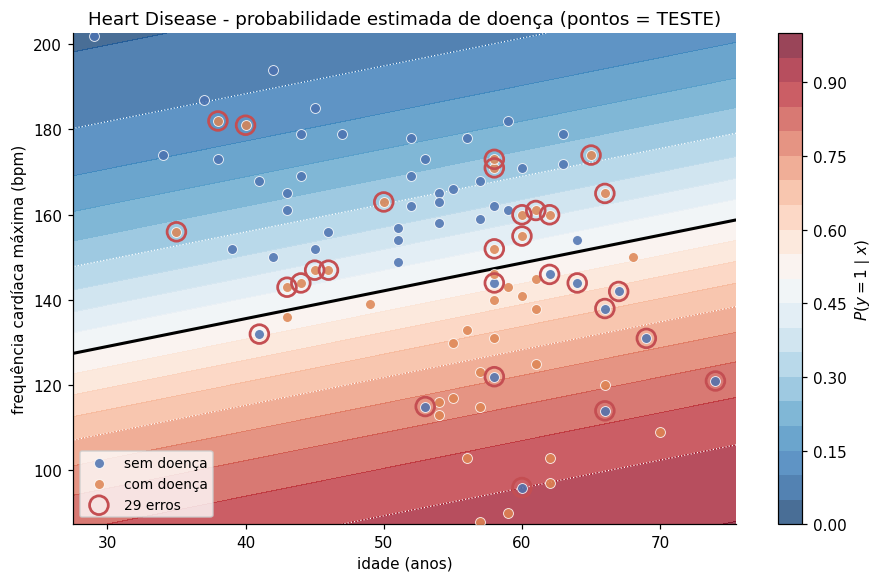

In [35]:
CAMINHO_HEART = Path("../../dados/heart-cleveland.csv")
URL_HEART = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
             "main/dados/heart-cleveland.csv")
heart = pd.read_csv(CAMINHO_HEART if CAMINHO_HEART.exists() else URL_HEART)
heart = heart.rename(columns={"Age": "idade", "MaxHR": "freq_card_max", "AHD": "doenca"})

Xh = heart[["idade", "freq_card_max"]].to_numpy(dtype=float)
yh = (heart["doenca"] == "Yes").astype(int).to_numpy()

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    Xh, yh, test_size=0.3, random_state=RANDOM_STATE, stratify=yh)

modelo_h = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xh_tr, yh_tr)
print(f"{len(yh)} pacientes    {yh.mean():.1%} com doença")
print(f"Acurácia no treino: {modelo_h.score(Xh_tr, yh_tr):.1%}")
print(f"Acurácia no teste:  {modelo_h.score(Xh_te, yh_te):.1%}")
print(f"Erro do majoritário: {min(yh.mean(), 1 - yh.mean()):.1%}")

coef = modelo_h[-1].coef_[0]
print(f"\ntheta(idade padronizada)         = {coef[0]:+.3f}")
print(f"theta(freq_card_max padronizada) = {coef[1]:+.3f}")

fig, ax = plt.subplots(figsize=(8.4, 5.4))
plota_regioes(modelo_h, Xh_te, yh_te, ax, rotulos=["sem doença", "com doença"],
              probabilidade=True)
ax.set_xlabel("idade (anos)")
ax.set_ylabel("frequência cardíaca máxima (bpm)")
ax.set_title("Heart Disease - probabilidade estimada de doença (pontos = TESTE)")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

In [36]:
# Cinco pacientes do conjunto de teste, com a probabilidade que o modelo atribui.
proba_h = modelo_h.predict_proba(Xh_te)[:, 1]
ordem = np.argsort(proba_h)
selecao = np.concatenate([ordem[:2], ordem[len(ordem) // 2:len(ordem) // 2 + 1], ordem[-2:]])
incerto = ((proba_h > 0.3) & (proba_h < 0.7)).mean()
print(f"Probabilidades no teste: de {proba_h.min():.3f} a {proba_h.max():.3f}")
print(f"{incerto:.0%} dos pacientes de teste caem na faixa 0,3 - 0,7, "
      "onde o modelo praticamente não se compromete.\n")
print(pd.DataFrame({
    "idade": Xh_te[selecao, 0].astype(int),
    "freq_card_max": Xh_te[selecao, 1].astype(int),
    "P(doença)": proba_h[selecao].round(3),
    "predição (limiar 0,5)": np.where(proba_h[selecao] >= 0.5, "doente", "saudável"),
    "verdade": np.where(yh_te[selecao] == 1, "doente", "saudável"),
}).to_string(index=False))

Probabilidades no teste: de 0.045 a 0.920
47% dos pacientes de teste caem na faixa 0,3 - 0,7, onde o modelo praticamente não se compromete.

 idade  freq_card_max  P(doença) predição (limiar 0,5)  verdade
    29            202      0.045              saudável saudável
    42            194      0.085              saudável saudável
    62            160      0.397              saudável   doente
    59             90      0.918                doente   doente
    57             88      0.920                doente   doente


**Responda:**

a) Os dois coeficientes têm **sinais opostos**. Traduza cada um em uma frase sobre
   risco de doença coronariana. O sinal da frequência cardíaca máxima faz sentido
   clínico?

b) A acurácia no teste fica bem abaixo dos 96% dos pinguins. Por quê? Que diferença
   entre os dois problemas isso revela - e olhe de novo o mapa de probabilidades
   antes de responder.

c) Quase metade dos pacientes de teste recebe uma probabilidade entre 0,3 e 0,7 -
   e nenhum recebe 0,01 ou 0,99. Isso é um defeito do modelo, ou é o modelo dizendo
   algo honesto?

d) Um cardiologista vai usar esse modelo para decidir quem faz um exame adicional
   barato e sem risco. Você recomendaria o limiar 0,5? Justifique com a tabela de
   limiares da seção 10 em mente (mesmo raciocínio, outra base).

🎯 **Conclusão do Exercício 3**

a) O coeficiente da **idade é positivo**: mais idade, maior $\theta^T x$, maior a
   probabilidade estimada de doença. O da **frequência cardíaca máxima é negativo**:
   quanto mais alto o pico de batimentos atingido no teste de esforço, **menor** a
   probabilidade. Faz sentido clínico - conseguir chegar a uma frequência alta durante
   o exercício é sinal de que o coração responde bem à demanda; quem tem obstrução
   coronariana costuma interromper o teste antes.

b) Os pinguins são medidos com paquímetro e a espécie é um fato biológico; a doença
   coronariana depende de dezenas de fatores que **não estão** nessas duas colunas
   (colesterol, tipo de dor torácica, resultado da fluoroscopia). As duas nuvens de
   pacientes se sobrepõem muito. Não é o modelo que é fraco: é a **informação
   disponível** que não determina a resposta. É a mesma conclusão do item (d) do
   exercício 1, agora com dados reais e alto custo humano.

c) É honestidade. Probabilidade perto de 0,5 quer dizer "com essas duas medidas, eu
   não sei" - e é o que se espera quando as duas nuvens se sobrepõem. Um modelo que
   cuspisse 0,99 nessa faixa estaria **mal calibrado** e seria muito mais perigoso:
   daria confiança onde não há. Essa é a grande vantagem de olhar `predict_proba` em
   vez de só `predict` - e sugere um terceiro caminho, além de "doente" e "saudável":
   devolver os casos da faixa cinzenta para avaliação humana.

d) Não. Se o exame é barato e sem risco, o custo de um **falso negativo** (mandar
   para casa um paciente doente) é muito maior que o de um falso positivo (um exame a
   mais). Vale **baixar** o limiar - para 0,3 ou 0,25 -, aumentando a revocação à
   custa da precisão, exatamente como na seção 10. E vale dizer o óbvio: um modelo
   com duas variáveis e ~70% de acurácia é material didático, não instrumento
   clínico.

---
## Para a próxima aula

Hoje o scikit-learn encontrou o $\theta$ para nós. Na próxima aula prática vamos
fazer o que os slides pedem no exercício final: **implementar a regressão logística
do zero**, com a função de custo de entropia cruzada e o gradiente descendente -
repetindo o que fizemos na aula 02 com a regressão linear e conferindo, no fim, que
os nossos $\theta$ batem com os do `LogisticRegression`.

Duas perguntas para levar na cabeça até lá:

1. O passo do gradiente na regressão logística é
   $\theta_j := \theta_j - \alpha \frac{1}{m}\sum (h(x^{(i)}) - y^{(i)}) x_j^{(i)}$ -
   **idêntico** ao da regressão linear. Se a fórmula é a mesma, o que mudou?
2. Por que trocar o erro quadrático pela entropia cruzada resolve o problema do
   slide 14? O que é uma função **convexa** e por que o gradiente descendente gosta
   tanto delas?